# **Facial Emotion Detection**

## **Problem Definition**

**The context:** Why is this problem important to solve?<br>
**The objectives:** What is the intended goal?<br>
**The key questions:** What are the key questions that need to be answered?<br>
**The problem formulation:** What are we trying to solve using data science?



## **About the dataset**

The data set consists of 3 folders, i.e., 'test', 'train', and 'validation'. 
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


## **Mounting the Drive**

**NOTE:**  Please use Google Colab from your browser for this notebook. **Google.colab is NOT a library that can be downloaded locally on your device.**

## **Importing the Libraries**

In [ ]:
# Docker with GPU
# http://localhost:8888

SyntaxError: invalid syntax (196495637.py, line 2)

In [ ]:
# =============================================================================
# LIBRARIES
# =============================================================================

# standart ML libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# classification
from sklearn.metrics import classification_report, confusion_matrix, f1_score
# to solve problem with unbalanced classes
from sklearn.utils.class_weight import compute_class_weight 

# tensorflow
import tensorflow as tf
import keras
from keras import layers

# additional libraries
from PIL import Image
from collections import Counter
import os, math, random, itertools, glob
import json
from pathlib import Path
from IPython.display import HTML, display

# tensorboard
from keras.callbacks import TensorBoard

In [ ]:
# =============================================================================
# CONSTANTS
# =============================================================================

# data paths
DATA_DIR = Path("../data")
TRAIN_DATA_DIR = Path("../data/train")
VALIDATION_DATA_DIR = Path("../data/validation")
TEST_DATA_DIR = Path("../data/test")

# models, runs, checkpoints paths
MODELS_DIR = Path("../models")
RUNS_DIR = Path("../runs")
REPORTS_DIR = Path("../reports")
SUMMARY_CSV = REPORTS_DIR / "models_summary.csv"

# check only pictures
ALLOWED_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

# data parameters
NUM_CLASSES = 4

import warnings

# suppress warnings
warnings.filterwarnings('ignore')

In [ ]:
# =============================================================================
# RANDOM SEED
# =============================================================================

# fixed random seed for reproducibility
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [ ]:
# =============================================================================
# CLEANUP - RUN BEFORE FULL TRAINING
# =============================================================================

import shutil

print("=" * 70)
print("CLEANING UP OLD ARTIFACTS")
print("=" * 70)

# Clear runs directory
if RUNS_DIR.exists():
    shutil.rmtree(RUNS_DIR)
    print("Cleared runs directory")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# Clear old models
old_models = [
    "best_cnn_baseline.keras",
    "best_cnn_deep_regularized.keras",
    "best_vgg16.keras",
    "best_resnet50v2.keras",
    "best_efficientnetv2b2.keras",
    "best_complex_cnn.keras"
]

for model_file in old_models:
    model_path = MODELS_DIR / model_file
    if model_path.exists():
        model_path.unlink()
        print(f"Removed old model: {model_file}")

# Clear summary CSV for new run
if SUMMARY_CSV.exists():
    SUMMARY_CSV.unlink()
    print("✓ Cleared models summary CSV")

print("=" * 70)
print("Cleanup complete! Ready for fresh training.")
print("=" * 70)

CLEANING UP OLD ARTIFACTS
✓ Cleared runs directory
✓ Removed old model: best_cnn_baseline.keras
✓ Removed old model: best_cnn_deep_regularized.keras
✓ Removed old model: best_vgg16.keras
✓ Removed old model: best_resnet50v2.keras
✓ Removed old model: best_complex_cnn.keras
✓ Cleared models summary CSV
✓ Cleanup complete! Ready for fresh training.


In [ ]:
# =============================================================================
# TENSORBOARD MONITORING SETUP
# =============================================================================

print("=" * 100)
print("TENSORBOARD MONITORING")
print("=" * 100)
print("\nTensorBoard will log training progress for all models.")
print("\n📊 To view TensorBoard during training:")
print("\n1. Open a new terminal")
print("2. Navigate to project directory")
print("3. Run: tensorboard --logdir=runs")
print("4. Open in browser: http://localhost:6006")
print("\nOr in Docker:")
print("docker exec facial-emotion-recognition-gpu tensorboard --logdir=runs --host=0.0.0.0 --port=6006")
print("Then open: http://localhost:6006")
print("\n" + "=" * 100)
print("\n✓ TensorBoard callbacks configured for all models")
print("✓ Logs will be saved to: runs/tensorboard_logs_*")
print("=" * 100)

In [ ]:
# =============================================================================
# TENSORBOARD UTILITIES
# =============================================================================

def launch_tensorboard(logdir="runs/tensorboard", port=6006):
    """
    Launch TensorBoard server.
    
    Args:
        logdir: Directory with TensorBoard logs
        port: Port for TensorBoard server
    """
    import subprocess
    import threading
    
    def run_tensorboard():
        subprocess.run([
            "tensorboard",
            f"--logdir={logdir}",
            f"--port={port}",
            "--host=0.0.0.0"
        ])
    
    # Run TensorBoard in background thread
    thread = threading.Thread(target=run_tensorboard, daemon=True)
    thread.start()
    
    print(f"✓ TensorBoard started at http://localhost:{port}")
    print(f"✓ Monitoring directory: {logdir}")

# Опционально: запустить TensorBoard автоматически
# launch_tensorboard()

In [ ]:
# =============================================================================
# FULL TRAINING RUN - CONFIGURATION
# =============================================================================

import time
FULL_RUN_START_TIME = time.time()
FULL_RUN_START_STR = time.strftime("%Y-%m-%d %H:%M:%S")

print("=" * 100)
print("FULL TRAINING RUN STARTED")
print("=" * 100)
print(f"Start time: {FULL_RUN_START_STR}")
print(f"Random seed: {RANDOM_SEED}")
print(f"")
print("Models to train:")
print("  1. Baseline CNN")
print("  2. Deep Regularized CNN")
print("  3. VGG16 Transfer Learning")
print("  4. ResNet50V2 Transfer Learning")
print("  5. EfficientNetV2B2 Transfer Learning")
print("  6. Complex Custom CNN (5 Blocks)")
print("")
print("Estimated total time: 4-8 hours")
print("=" * 100)

### **Let us load and unzip the data**

**Note:** 
- You must download the dataset from the link provided on Olympus and upload the same on your Google drive before executing the code in the next cell.
- In case of any error, please make sure that the path of the file is correct as the path may be different for you.

## **Visualizing our Classes**

Let's look at our classes. 

**Write down your observation for each class. What do you think can be a unique feature of each emotion, that separates it from the remaining classes?**

In [5]:
# =============================================================================
# Utility functions for visualization
# =============================================================================

def _read_image(path, img_size=(224, 224)):
    """
    Load and preprocess image: grayscale, resize, normalize to [0,1].
    """
    img = Image.open(path).convert("L")
    if img.size != (img_size[1], img_size[0]):
        img = img.resize((img_size[1], img_size[0]), Image.Resampling.BILINEAR)
    return np.expand_dims(np.asarray(img, dtype=np.float32) / 255.0, axis=-1)

def _sample_paths(root_dir, class_name, n=12, seed=42):
    """
    Pick up to n random image paths for a given class.
    """
    paths = sorted(glob.glob(str(Path(root_dir) / class_name / "*")))
    return random.Random(seed).sample(paths, min(n, len(paths)))

def _create_image_grid(images, rows, cols, class_names=None):
    """
    Create a grid of images with optional class names as titles.
    """
    fig, axes = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
    axes = np.atleast_1d(axes).ravel()
    
    for i, (ax, img) in enumerate(zip(axes, images)):
        ax.imshow(img.squeeze(-1), cmap="gray", vmin=0, vmax=1)
        if class_names is not None:
            ax.set_title(class_names[i])
        ax.axis("off")
    
    for ax in axes[len(images):]:
        ax.axis("off")
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

def plot_class_examples(root_dir, class_name, n=12, img_size=(224, 224), seed=42):
    """
    Show n random images for a given class.
    """
    paths = _sample_paths(root_dir, class_name, n, seed)
    images = [_read_image(p, img_size) for p in paths]
    
    cols = min(6, len(images))
    rows = (len(images) + cols - 1) // cols
    
    fig = _create_image_grid(images, rows, cols)
    fig.suptitle(f"Class: {class_name} (n={len(images)})")
    plt.show()

def plot_batch(gen, rows=3, cols=6, title="Sample batch"):
    """
    Show a grid from a single batch of a DirectoryIterator.
    """
    X, y = next(gen)
    class_names = [gen.class_indices.get(i) for i in np.argmax(y, axis=1)]
    
    n = min(rows*cols, X.shape[0])
    fig = _create_image_grid(X[:n], rows, cols, class_names[:n])
    fig.suptitle(title)
    plt.show()

### **Happy**

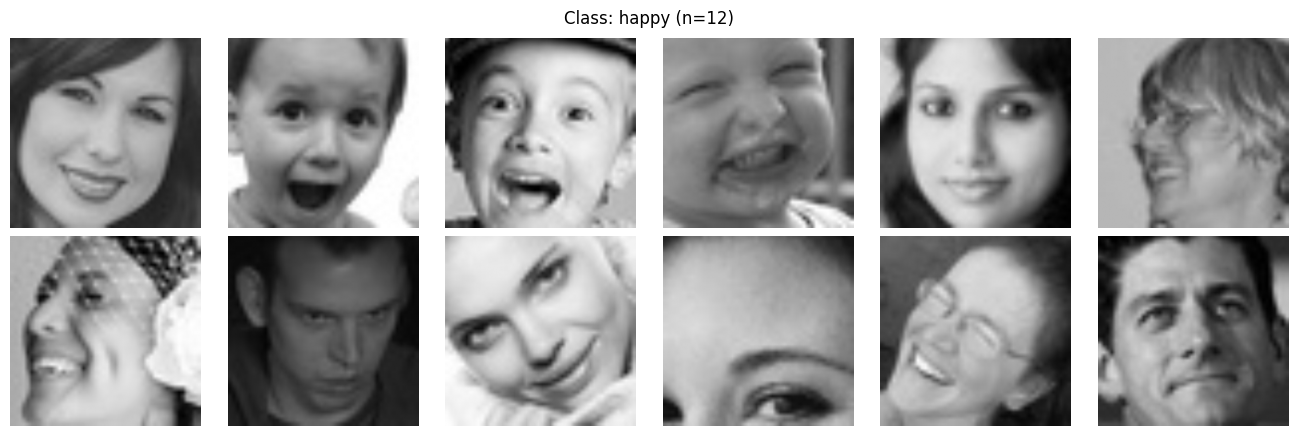

In [6]:
plot_class_examples(TRAIN_DATA_DIR, "happy",    n=12, img_size=(224,224))

**Observations and Insights:**

*Expression Diversity:*
- Wide range from subtle smiles to exuberant laughter
- Mix of closed-mouth contentment and open-mouthed, tooth-revealing grins
- Eye expressions vary from soft looks to crinkled, squinting laughter

*Demographics:*
- Diverse age groups: toddlers, children, young adults, middle-aged
- Both genders represented with various ethnicities

*Key Facial Features:*
- Mouth: Gentle upturned lips to wide-open laughter
- Eyes: Bright, alert to crinkled corners indicating joy
- Cheeks: Raised cheeks and dimples in many images
- Head positioning: Natural tilts and angles

*Expression Intensity:*
- Overt joy (open-mouthed laughter, squeezed eyes)
- Subtle contentment (gentle smiles, soft eyes)
- One ambiguous expression that may challenge classification

**Technical Notes:**
- Consistent grayscale format focuses on facial structure
- Good lighting and contrast quality
- Some profile views and partial faces may present classification challenges

This sample effectively demonstrates the complexity of human happiness expressions, highlighting both the variety and potential classification difficulties for emotion recognition models.

### **Sad**

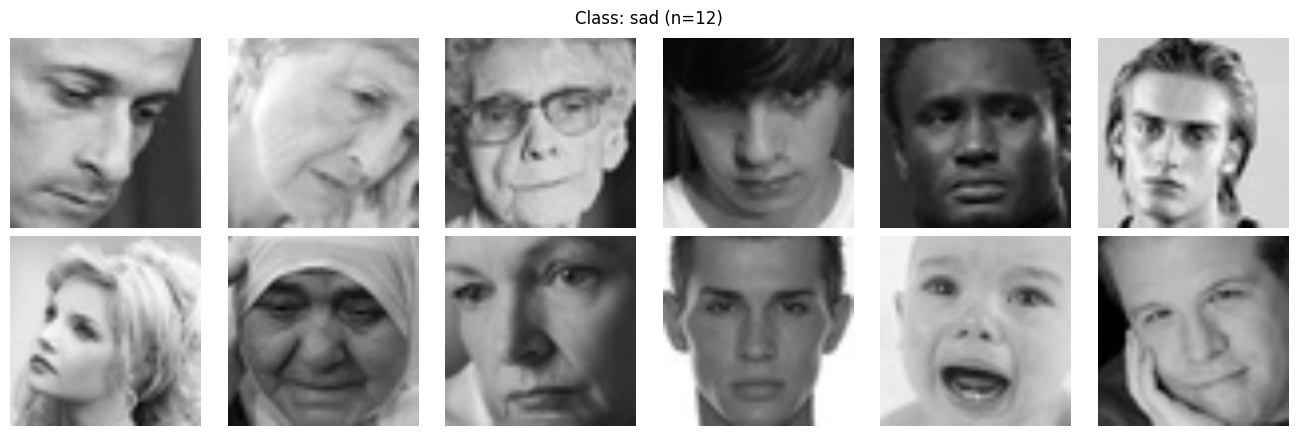

In [7]:
plot_class_examples(TRAIN_DATA_DIR, "sad", n=12, img_size=(224,224))

**Observations and Insights:**

*Expression Diversity:*
- Range from subtle somberness to overt distress and crying
- Mix of downturned mouths, heavy eyelids, and furrowed brows
- One baby actively crying, others show subdued sadness

*Demographics:*
- Diverse ages: baby, children, adults, elderly
- Both genders with various ethnicities

*Key Facial Features:*
- Mouth: Downturned corners, some slightly open as if sighing
- Eyes: Heavy, downcast, or averted; visible tears in one image
- Eyebrows: Furrowed or drawn together indicating worry
- Head positioning: Often tilted down or supported by hand

*Expression Intensity:*
- Overt distress (crying baby, visible tears)
- Subtle melancholy (downcast eyes, slight frowns)
- Contemplative sadness (hand supporting head)

**Technical Notes:**
- Consistent grayscale format maintains focus on facial structure
- Good contrast for detecting subtle expression changes
- Some images show partial faces or profile views

This sample effectively demonstrates the complexity of sadness expressions, from intense emotional distress to subtle melancholy, highlighting the range of features the model must learn to recognize.

### **Neutral**

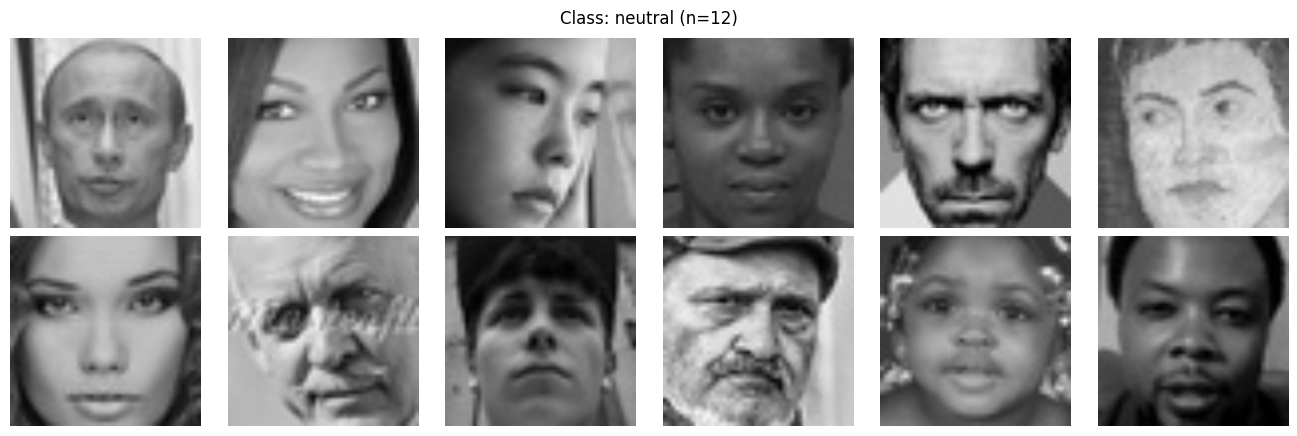

In [8]:
plot_class_examples(TRAIN_DATA_DIR, "neutral", n=12, img_size=(224,224))

**Observations and Insights:**

*Expression Diversity:*
- Consistently calm, relaxed, and devoid of strong emotion
- Range from completely impassive to subtly contemplative
- No overt signs of happiness, sadness, anger, or surprise

*Demographics:*
- Diverse ages: young child, adults, elderly
- Both genders with various ethnicities

*Key Facial Features:*
- Mouth: Mostly closed, straight, or very slightly relaxed lips
- Eyes: Generally open, looking directly or slightly averted
- Eyebrows: Relaxed, neither furrowed nor raised
- Forehead: Smooth, without prominent expression wrinkles

*Expression Intensity:*
- Consistently low intensity across all images
- No strong emotional cues present
- Subtle variations in attentiveness or focus

**Technical Notes:**
- Grayscale format helps focus on structural features
- Good for baseline comparison with emotional expressions


Some images show slight variations that could be challenging to classify
This sample effectively demonstrates the "neutral" baseline state, providing a clear contrast to emotional expressions and highlighting the importance of subtle facial feature detection for accurate classification.

### **Surprised**

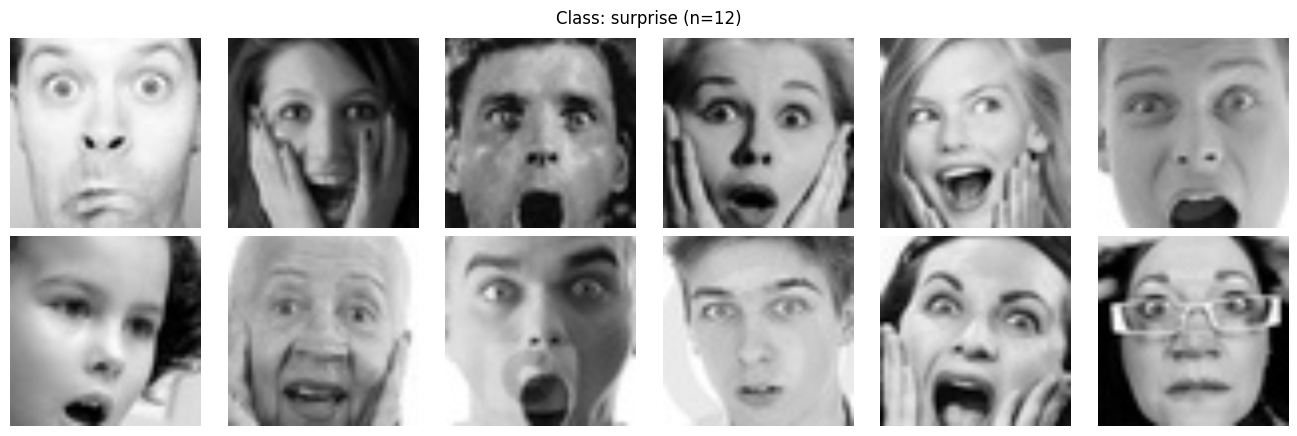

In [9]:
plot_class_examples(TRAIN_DATA_DIR, "surprise", n=12, img_size=(224,224))

**Observations and Insights:**

*Expression Diversity:*
- Consistently features wide-open eyes and open mouths
- Range from wide-eyed shock to more subdued gasps
- Some subjects have hands raised to faces, amplifying the reaction

*Demographics:*
- Diverse ages: child, young adults, middle-aged, elderly
- Both genders with various facial features

*Key Facial Features:*
- Eyes: Universally wide open, showing whites above/below iris
- Eyebrows: Typically raised, creating smooth forehead
- Mouth: Open in "O" or oval shape, suggesting gasp
- Hands: Several images show hands covering cheeks/mouth

*Expression Intensity:*
- Predominantly high intensity with exaggerated features
- Clear, distinct surprise cues across all images
- Consistent visual markers make this class well-defined

**Technical Notes:**
- Grayscale format maintains focus on structural changes
- High contrast between eye whites and pupils aids detection
- Hand gestures add complexity but reinforce surprise signal


This sample effectively demonstrates the most visually distinct emotion class, with consistent and exaggerated facial features that should be relatively easy for the model to learn and classify accurately.

## **Checking Distribution of Classes**

### Utilites

##### Data visualisation (tables, dict, dataframes)

In [11]:
# =============================================================================
# UTILITY DATA VISUALISATION
# =============================================================================

def _to_py(x):
    """numpy scalars -> python types; leave others as-is."""
    return x.item() if isinstance(x, np.generic) else x

def print_dict_table(
    data: dict,
    title: str | None = None,
    show_percent: bool = True,
    key_header: str = "Class",
    val_header: str = "Count",
    pct_header: str = "Percent",
    percent_decimals: int = 1,
    value_decimals: int = 3,
):
    """
    Pretty-print a dict as a text table with optional percent column.

    Example:
        counts = {"happy": 3976, "neutral": 3978, "sad": 3982, "surprise": 3173}
        print_dict_table(counts, title="Train set", show_percent=True)
        
        weights = {"happy": 0.95, "neutral": 1.2, "sad": 0.88, "surprise": 1.15}
        print_dict_table(weights, title="Class weights", show_percent=False)
    """
    # normalize & basic checks
    keys = list(data.keys())
    vals = [ _to_py(data[k]) for k in keys ]
    try:
        nums = [ float(v) for v in vals ]
    except Exception as e:
        raise ValueError("All values must be numeric to print this table.") from e

    total = sum(nums)
    # formatting helpers
    def fmt_count(x):
        if x == int(x):
            return f"{int(x):,}"
        else:
            return f"{x:,.{value_decimals}f}"

    def fmt_percent(x):
        return f"{x:.{percent_decimals}f}%"

    # column widths
    key_w = max(len(key_header), *(len(str(k)) for k in keys))
    val_w = max(len(val_header), *(len(fmt_count(v)) for v in nums))
    pct_w = max(len(pct_header), len(f"{0:.{percent_decimals}f}%"))

    if title:
        print(title)

    # header
    if show_percent and total > 0:
        print(f"{key_header:<{key_w}}  {val_header:>{val_w}}  {pct_header:>{pct_w}}")
        print(f"{'-'*key_w}  {'-'*val_w}  {'-'*pct_w}")
    else:
        print(f"{key_header:<{key_w}}  {val_header:>{val_w}}")
        print(f"{'-'*key_w}  {'-'*val_w}")

    # rows
    for k, v in zip(keys, nums):
        if show_percent and total > 0:
            pct = 100.0 * v / total
            print(f"{k:<{key_w}}  {fmt_count(v):>{val_w}}  {fmt_percent(pct):>{pct_w}}")
        else:
            print(f"{k:<{key_w}}  {fmt_count(v):>{val_w}}")

    # footer (total)
    if show_percent and total > 0:
        print(f"{'-'*key_w}  {'-'*val_w}  {'-'*pct_w}")
        print(f"{'TOTAL':<{key_w}}  {fmt_count(total):>{val_w}}  {fmt_percent(100.0):>{pct_w}}")
    else:
        print(f"{'-'*key_w}  {'-'*val_w}")
        print(f"{'TOTAL':<{key_w}}  {fmt_count(total):>{val_w}}")

# ---------- Dataframe HTML-style visualisation ----------
def display_df(df, rows = 10, show_index = False):
    """
    Display a DataFrame in HTML format.
    Args:
        df: DataFrame to display
        rows: Number of rows to display
        show_index: Whether to show row indices
    """
    if rows==0:
        display(HTML(df.to_html(index=show_index)))
    else:
        display(HTML(df.head(rows).to_html(index=show_index)))

##### Data distribution

In [12]:
# ---------- Count images for distibution ----------

# collect subdirs
def list_classes(root_dir):
    """Return sorted list of class folders in root_dir."""
    return sorted([d for d in os.listdir(root_dir)
                   if os.path.isdir(os.path.join(root_dir, d))])

# count images for distribution
def count_images_by_class(root_dir, classes=None, exts=ALLOWED_EXTS):
    """
    Count images per class in a 'root_dir/<class>/*.ext' structure.
    Returns (classes, counts).
    """
    if classes is None:
        classes = list_classes(root_dir)

    counts = []
    for c in classes:
        cdir = os.path.join(root_dir, c)
        n = sum(
            1 for f in os.listdir(cdir)
            if os.path.isfile(os.path.join(cdir, f))
            and f.lower().endswith(exts)
        )
        counts.append(n)
    return classes, np.array(counts, dtype=int)

# plot barplot
def plot_class_distribution_dir(root_dir, classes=None, title="Class distribution"):
    """Plot bar chart of class counts for images stored in folders."""
    classes, counts = count_images_by_class(root_dir, classes)
    total = counts.sum()

    plt.figure(figsize=(8, 4))
    bars = plt.bar(range(len(classes)), counts)
    plt.xticks(range(len(classes)), classes)
    plt.ylabel("images")
    plt.title(title)
    plt.grid(axis="y", alpha=0.25)
    for b, v in zip(bars, counts):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + max(total*0.0005, 0.05),
                 f"{v}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

        # quick summary
    counts_dict = dict(zip(classes, counts))
    print_dict_table(counts_dict, title=title, show_percent=True)    

# check, if all classes matches
def assert_same_class_set(*dirs):
    """Sanity check: the same class set across splits."""
    ref = set(list_classes(dirs[0]))
    for d in dirs[1:]:
        cur = set(list_classes(d))
        if cur != ref:
            raise ValueError(f"Class mismatch: {dirs[0]} vs {d} -> {ref} vs {cur}")
    return sorted(ref)

In [13]:
# check class names in all dirs
CLASS_LABELS = assert_same_class_set(TRAIN_DATA_DIR, VALIDATION_DATA_DIR, TEST_DATA_DIR)

##### Train-set distribution

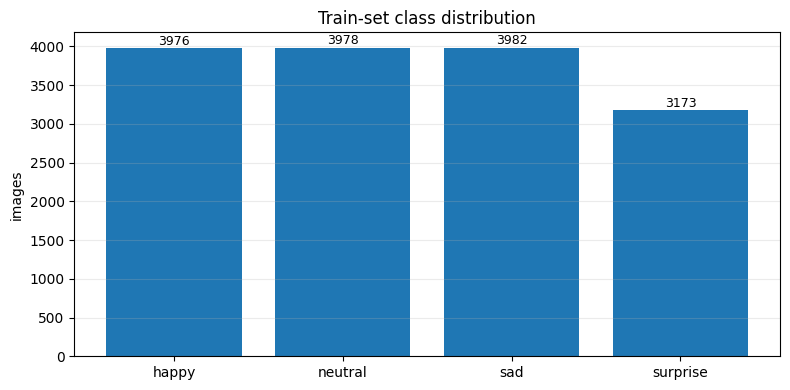

Train-set class distribution
Class     Count  Percent
--------  -----  -------
happy     3,976    26.3%
neutral   3,978    26.3%
sad       3,982    26.4%
surprise  3,173    21.0%
--------  -----  -------
TOTAL     15,109   100.0%


In [14]:
# train-set distribution
plot_class_distribution_dir(TRAIN_DATA_DIR, CLASS_LABELS, "Train-set class distribution")

**Observations and Insights:**

* The class distribution is roughly balanced across happy, neutral and sad, with slight under-representation of surprise** (≈15–20% fewer images).

* With this mild skew, a classifier may under-predict surprise** unless we compensate a bit (e.g., by monitoring per-class recall/F1, and optionally using light class weights or slightly stronger augmentation for surprise).

##### Validation-set distribution

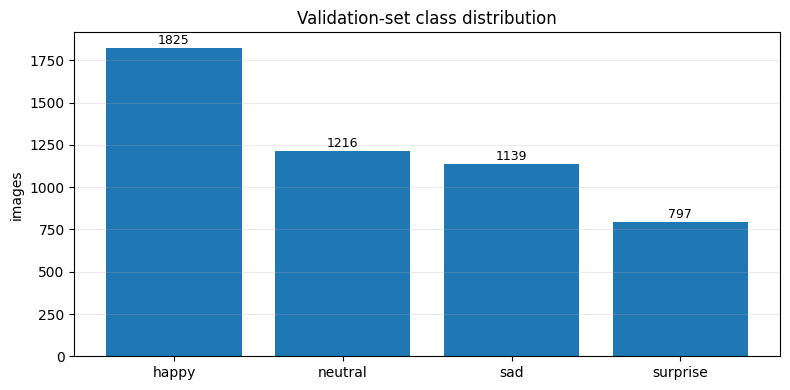

Validation-set class distribution
Class     Count  Percent
--------  -----  -------
happy     1,825    36.7%
neutral   1,216    24.4%
sad       1,139    22.9%
surprise    797    16.0%
--------  -----  -------
TOTAL     4,977   100.0%


In [15]:
# validation-set distribution
plot_class_distribution_dir(VALIDATION_DATA_DIR, CLASS_LABELS, "Validation-set class distribution")


* The validation split is noticeably imbalanced: happy dominates (≈1.8k) while surprise is the smallest (≈0.8k).
* Because of this skew, val_accuracy can be misleading—a model that over-predicts happy can look “good” while underperforming on minority classes.
* To avoid biased model selection/early-stopping, we should evaluate with class-insensitive metrics:
    * Macro-F1 (unweighted mean over classes),
    * Balanced accuracy (mean recall across classes),
    * Per-class precision/recall/F1 + the confusion matrix.
* If we still see systematic errors (e.g., poor recall for surprise), we can add class weights during training to up-weight minority classes.

##### Test-set distribution

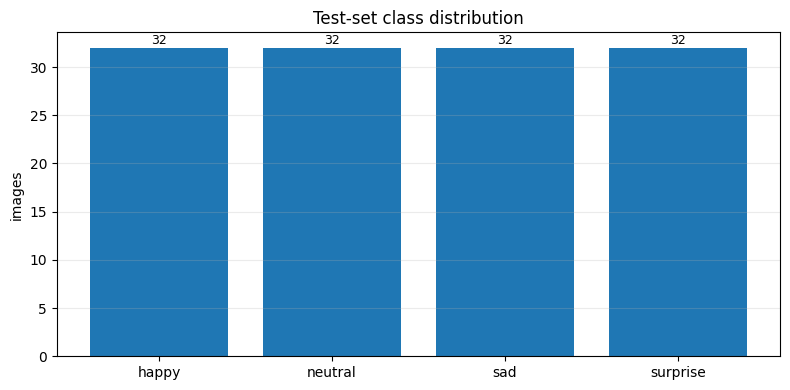

Test-set class distribution
Class     Count  Percent
--------  -----  -------
happy        32    25.0%
neutral      32    25.0%
sad          32    25.0%
surprise     32    25.0%
--------  -----  -------
TOTAL       128   100.0%


In [16]:
# test-set distribution
plot_class_distribution_dir(TEST_DATA_DIR, CLASS_LABELS, "Test-set class distribution")

* The test set is perfectly balanced (32 images per class) and small.
* That’s ideal for an unbiased final check, but the small size means higher variance—reporting macro-F1 (and optionally confidence intervals or at least per-class results) will make conclusions more robust.
* The test set is not used for training or model selection, so its balance does not affect the training dynamics.

**Think About It:** 
* Are the classes equally distributed? If not, do you think the imbalance is too high? Will it be a problem as we progress?
* Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?

*Primary approach (keep current splits, fix evaluation):*

* Keep the provided train/val/test splits for now.
* Select/stop models using macro-F1 (or balanced accuracy) on validation, not plain accuracy.
* Always show the confusion matrix and per-class metrics.
* Optionally pass class_weight (computed from the train distribution) if minority-class recall lags.

*Fallback / comparative approach (re-split):*

* If validation metrics/CM still look biased, we will merge train+val and re-split stratified (e.g., 80/20) to obtain a more balanced validation set.
* Test set remains untouched for the final, unbiased evaluation.

*Option to compare both:*

It’s acceptable to train/evaluate both setups (original vs. stratified re-split) and pick the one with better macro-F1 on a held-out validation. This doesn’t violate the task, as long as the test set is used only once for the final report.

In [17]:
# =============================================================================
# TRAINING CONFIGURATION
# =============================================================================

# Metric configuration - choose based on your model setup
# Options: "accuracy", "sparse_categorical_accuracy", "categorical_accuracy"
METRIC_NAME = "sparse_categorical_accuracy"  # For integer labels
VAL_METRIC_NAME = f"val_{METRIC_NAME}"

print(f"Using metric: {METRIC_NAME}")
print(f"Validation metric: {VAL_METRIC_NAME}")

Using metric: sparse_categorical_accuracy
Validation metric: val_sparse_categorical_accuracy


## **Creating our Data Loaders**

In this section, we are creating data loaders that we will use as inputs to our Neural Network.

**You have two options for the color_mode. You can set it to color_mode = 'rgb' or color_mode = 'grayscale'. You will need to try out both and see for yourself which one gives better performance.**

##### Channels audit

In [18]:
# =============================================================================
# AUDIT
# =============================================================================

# check if we have images with different channels count
def audit_image_channels(root_dir, splits=("train","validation","test"), 
                         max_per_class=300, exts=ALLOWED_EXTS):
    """
    Scan a subset of images and report PIL modes (L/RGB/RGBA/…)
    and example shapes (H, W, C) per split.
    """
    for split in splits:
        split_dir = os.path.join(root_dir, split)
        if not os.path.isdir(split_dir):
            print(f"[{split}] not found -> {split_dir}")
            continue

        mode_counts = Counter()
        shape_counts = Counter()
        corrupt = 0

        for cls in sorted(os.listdir(split_dir)):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir): 
                continue

            files = [f for f in os.listdir(cls_dir) if f.lower().endswith(exts)]
            random.shuffle(files)
            for f in files[:max_per_class]:
                p = os.path.join(cls_dir, f)
                try:
                    with Image.open(p) as im:
                        mode_counts[im.mode] += 1       # e.g., 'L', 'RGB', 'RGBA'
                        c = len(im.getbands())          # bands -> channels
                        shape_counts[(im.height, im.width, c)] += 1
                except Exception:
                    corrupt += 1

        print(f"\n[{split}]  modes: {dict(mode_counts)}  |  corrupt: {corrupt}")
        # show a few unique shapes
        ex_shapes = list(shape_counts.items())[:5]
        ex_shapes = [(s, n) for s, n in ex_shapes]
        print(f"[{split}]  example (H,W,C) counts: {ex_shapes}")


audit_image_channels(DATA_DIR)


[train]  modes: {'L': 1200}  |  corrupt: 0
[train]  example (H,W,C) counts: [((48, 48, 1), 1200)]

[validation]  modes: {'L': 1200}  |  corrupt: 0
[validation]  example (H,W,C) counts: [((48, 48, 1), 1200)]

[test]  modes: {'L': 128}  |  corrupt: 0
[test]  example (H,W,C) counts: [((48, 48, 1), 128)]


##### DATA-LOADERS

In [ ]:
# =============================================================================
# DATA-LOADERS
# =============================================================================

from keras.utils import image_dataset_from_directory

def make_generators(train_dir, val_dir, test_dir, img_size=(48,48),
                    color_mode="grayscale", batch_size=64, augment=True):
    
    # Define preprocessing function
    def preprocess_image(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label
    
    # Define augmentation function (fixed for TensorFlow compatibility)
    def augment_image(image, label):
        if augment:
            # Horizontal flip
            image = tf.image.random_flip_left_right(image)
            
            # Random brightness
            image = tf.image.random_brightness(image, 0.2)
            
            # Random contrast
            image = tf.image.random_contrast(image, 0.8, 1.2)

            image = tf.keras.preprocessing.image.apply_affine_transform(
                image.numpy(), 
                shear=0.3,
                fill_mode='nearest'
            )            
            
            # Random rotation using tf.keras preprocessing
            # Note: rotation is applied differently in tf 2.x
            # We'll use a simple approach with limited rotation
            angle = tf.random.uniform([], -0.1, 0.1)  # radians
            image = tf.keras.preprocessing.image.apply_affine_transform(
                image.numpy(), theta=angle * 180 / 3.14159, 
                channel_axis=2, fill_mode='nearest'
            ) if hasattr(tf.keras.preprocessing.image, 'apply_affine_transform') else image
            
        return image, label
    
    # Alternative augmentation without rotation (more stable)
    def augment_image_simple(image, label):
        # Horizontal flip
        image = tf.image.random_flip_left_right(image)
        
        # Random brightness
        image = tf.image.random_brightness(image, 0.2)
        
        # Random contrast
        image = tf.image.random_contrast(image, 0.8, 1.2)
        
        # Clip to valid range
        image = tf.clip_by_value(image, 0.0, 1.0)
        
        return image, label
    
    print("-"*50)
    print("Train data:")
    train_ds = image_dataset_from_directory(
        train_dir,
        image_size=img_size,
        batch_size=batch_size,
        color_mode=color_mode,
        shuffle=True
    )
    train_ds = train_ds.map(preprocess_image)
    if augment:
        train_ds = train_ds.map(augment_image_simple)  # Using simple augmentation
    
    print("Validation data:")
    val_ds = image_dataset_from_directory(
        val_dir,
        image_size=img_size,
        batch_size=batch_size,
        color_mode=color_mode,
        shuffle=False
    )
    val_ds = val_ds.map(preprocess_image)
    
    print("Test data:")
    test_ds = image_dataset_from_directory(
        test_dir,
        image_size=img_size,
        batch_size=batch_size,
        color_mode=color_mode,
        shuffle=False
    )
    test_ds = test_ds.map(preprocess_image)
    
    return train_ds, val_ds, test_ds

In [20]:
# --- Data loaders used for training ---
COLOR_MODE = "grayscale"         # all images have one channel
IMG_SIZE = (48, 48)
IMAGE_SHAPE = (*IMG_SIZE, 1)
BATCH_SIZE = 64
AUGMENT    = False

train_gen, val_gen, test_gen = make_generators(
    train_dir = TRAIN_DATA_DIR,
    val_dir   = VALIDATION_DATA_DIR,
    test_dir  = TEST_DATA_DIR,
    img_size  = IMG_SIZE,
    color_mode= COLOR_MODE,
    batch_size= BATCH_SIZE,
    augment   = AUGMENT,
)

# quick sanity check
print("----- sanity check -----")
for xb, yb in train_gen.take(1):
    print(f"train batch: {xb.shape}, labels: {yb.shape}, color_mode={COLOR_MODE}")
    print(f"Image dtype: {xb.dtype}, Label dtype: {yb.dtype}")
    print(f"Image range: [{tf.reduce_min(xb):.3f}, {tf.reduce_max(xb):.3f}]")
    print(f"Labels shape: {yb.shape}")
    print(f"Labels dtype: {yb.dtype}")
    print(f"Unique labels: {tf.unique(yb)[0]}")
    break

--------------------------------------------------
Train data:
Found 15109 files belonging to 4 classes.
Validation data:
Found 4977 files belonging to 4 classes.
Test data:
Found 128 files belonging to 4 classes.
----- sanity check -----
train batch: (64, 48, 48, 1), labels: (64,), color_mode=grayscale
Image dtype: <dtype: 'float32'>, Label dtype: <dtype: 'int32'>
Image range: [0.000, 1.000]
Labels shape: (64,)
Labels dtype: <dtype: 'int32'>
Unique labels: [0 2 3 1]


In [21]:
# class weights to compensate imbalance during training
all_labels = []
for batch in train_gen.take(-1):
    _, labels = batch
    all_labels.extend(labels.numpy())

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels,
)
CLASS_WEIGHTS = {i: w for i, w in enumerate(weights)}
print_dict_table(CLASS_WEIGHTS, title="Class weights", val_header="Value", show_percent=False, value_decimals=3)    

Class weights
Class  Value
-----  -----
0      0.950
1      0.950
2      0.949
3      1.190
-----  -----
TOTAL  4.039


## **Model Building**

##### EVALUATION AND VISUALIZATION MODULE

In [22]:
# =============================================================================
# EVALUATION AND VISUALIZATION MODULE
# =============================================================================

def save_metrics(metrics: dict, out_json: Path):
    """
    Save any metrics/parameters to JSON file in readable format.
    """
    with open(out_json, "w") as f:
        json.dump(metrics, f, indent=2)

def save_history(history, out_csv: Path):
    """
    Save Keras training history to CSV file.
    """
    df = pd.DataFrame(history.history)
    df.to_csv(out_csv, index=False)

def make_run_dir(name: str) -> Path:
    """
    Create a unique directory for an experiment and return the path.
    """
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = RUNS_DIR / f"{ts}_{name}"
    (run_dir / "figs").mkdir(parents=True, exist_ok=True)
    (run_dir / "tb").mkdir(parents=True, exist_ok=True)
    return run_dir

def append_summary_row(row: dict):
    """Append a row to the general CSV summary of models."""
    df_new = pd.DataFrame([row])
    if SUMMARY_CSV.exists():
        df = pd.read_csv(SUMMARY_CSV)
        df = pd.concat([df, df_new], ignore_index=True)
    else:
        df = df_new
    df.to_csv(SUMMARY_CSV, index=False)

class ModelEvaluator:
    """
    Unified class for model evaluation, visualization, and artifact saving.
    Designed for modern tf.data.Dataset API.
    """
    
    def __init__(self, class_labels=None):
        """
        Initialize evaluator with class labels.
        
        Args:
            class_labels: List of class names (e.g., ['happy', 'sad', 'neutral', 'surprise'])
        """
        self.class_labels = class_labels or ['happy', 'sad', 'neutral', 'surprise']
    
    def get_predictions(self, model, test_dataset):
        """
        Get predictions from model on test dataset.
        
        Args:
            model: Trained Keras model
            test_dataset: tf.data.Dataset test data
            
        Returns:
            tuple: (y_true, y_pred, y_prob)
        """
        # Get predictions
        y_prob = model.predict(test_dataset, verbose=0)
        y_pred = y_prob.argmax(axis=1)
        
        # Get true labels from dataset
        y_true = []
        for batch in test_dataset.take(-1):
            _, labels_batch = batch
            y_true.extend(labels_batch.numpy())
        y_true = np.array(y_true)
        
        return y_true, y_pred, y_prob
    
    def compute_metrics(self, y_true, y_pred):
        """
        Compute comprehensive evaluation metrics.
        
        Args:
            y_true: True labels
            y_pred: Predicted labels
            
        Returns:
            dict: Dictionary of metrics
        """
        from sklearn.metrics import accuracy_score, f1_score, classification_report
        
        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        weighted_f1 = f1_score(y_true, y_pred, average="weighted")
        
        # Detailed classification report
        report = classification_report(
            y_true, y_pred, 
            target_names=self.class_labels, 
            digits=3, 
            output_dict=True
        )
        
        return {
            "accuracy": acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "classification_report": report
        }
    
    def plot_confusion_matrix(self, y_true, y_pred, save_path=None, 
                            normalize=True, title="Confusion Matrix"):
        """
        Plot and optionally save confusion matrix.
        
        Args:
            y_true: True labels
            y_pred: Predicted labels
            save_path: Path to save plot (optional)
            normalize: Whether to normalize the matrix
            title: Plot title
        """
        from sklearn.metrics import confusion_matrix
        
        cm = confusion_matrix(y_true, y_pred)
        
        if normalize:
            cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)
        
        plt.figure(figsize=(8, 6))
        im = plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        
        tick_marks = np.arange(len(self.class_labels))
        plt.xticks(tick_marks, self.class_labels, rotation=45, ha="right")
        plt.yticks(tick_marks, self.class_labels)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            txt = f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}"
            plt.text(j, i, txt, horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black", fontsize=10)
        
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(title)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        
        plt.show()
    
    def plot_training_history(self, history, save_path=None, title_suffix=""):
        """
        Plot training history (loss and accuracy curves).
        
        Args:
            history: Keras History object
            save_path: Path to save plot (optional)
            title_suffix: Suffix for plot titles
        """
        h = history.history
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Accuracy plot
        axes[0].plot(h["accuracy"], label="train", linewidth=2)
        axes[0].plot(h["val_accuracy"], label="validation", linewidth=2)
        axes[0].set_title(f"Accuracy{title_suffix}")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Accuracy")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Loss plot
        axes[1].plot(h["loss"], label="train", linewidth=2)
        axes[1].plot(h["val_loss"], label="validation", linewidth=2)
        axes[1].set_title(f"Loss{title_suffix}")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Loss")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        
        plt.show()
    
    def evaluate_and_save(self, model, test_dataset, output_dir, model_name="model"):
        """
        Complete evaluation pipeline: compute metrics, create plots, save artifacts.
        
        Args:
            model: Trained Keras model
            test_dataset: tf.data.Dataset test data
            output_dir: Directory to save artifacts
            model_name: Name for saved files
            
        Returns:
            dict: Evaluation metrics
        """
        
        # Get predictions
        y_true, y_pred, y_prob = self.get_predictions(model, test_dataset)
        
        # Compute metrics
        metrics = self.compute_metrics(y_true, y_pred)
        
        # Save classification report
        report_text = classification_report(
            y_true, y_pred, 
            target_names=self.class_labels, 
            digits=3
        )
        
        with open(output_dir / f"{model_name}_classification_report.txt", "w") as f:
            f.write(report_text)
        
        # Save confusion matrix plot
        self.plot_confusion_matrix(
            y_true, y_pred, 
            save_path=output_dir / f"{model_name}_confusion_matrix.png",
            title=f"Confusion Matrix - {model_name}"
        )
        
        # Save metrics to JSON
        save_metrics(metrics, output_dir / f"{model_name}_metrics.json")
        
        return metrics
    
    def print_summary(self, y_true, y_pred, metrics):
        """
        Print evaluation summary to console.
        
        Args:
            y_true: True labels
            y_pred: Predicted labels
            metrics: Dictionary of computed metrics
        """
        print("=" * 60)
        print("EVALUATION SUMMARY")
        print("=" * 60)
        print(f"Accuracy: {metrics['accuracy']:.3f}")
        print(f"Macro F1: {metrics['macro_f1']:.3f}")
        print(f"Weighted F1: {metrics['weighted_f1']:.3f}")
        print("\nDetailed Classification Report:")
        print(classification_report(y_true, y_pred, target_names=self.class_labels, digits=3))
        print("=" * 60)

In [ ]:
# =============================================================================
# MODEL SUMMARY FUNCTIONS
# =============================================================================

def create_model_summary(model, history, test_metrics, model_name="model", training_time=None):
    """
    Create comprehensive model summary for comparison.
    
    Args:
        model: Trained Keras model
        history: Training history
        test_metrics: Test evaluation metrics
        model_name: Name of the model
        
    Returns:
        dict: Summary row for comparison table
    """
    h = history.history
    
    summary = {
        "Model": model_name,
        "Parameters": int(model.count_params()),
        
        # Training metrics
        "Train_Acc_Final": float(h[METRIC_NAME][-1]),
        "Train_Loss_Final": float(h["loss"][-1]),
        
        # Validation metrics
        "Val_Acc_Best": float(np.max(h[VAL_METRIC_NAME])),
        "Val_Acc_Final": float(h[VAL_METRIC_NAME][-1]),
        "Val_Loss_Min": float(np.min(h["val_loss"])),
        "Val_Loss_Final": float(h["val_loss"][-1]),
        
        # Epochs
        "Total_Epochs": int(len(h["loss"])),
        "Best_Epoch": int(np.argmin(h["val_loss"]) + 1),
        
        # Test metrics
        "Test_Accuracy": float(test_metrics["accuracy"]),
        "Test_Macro_F1": float(test_metrics["macro_f1"]),
        "Test_Weighted_F1": float(test_metrics["weighted_f1"]),
        
        # Analysis
        "Overfitting": float(h[VAL_METRIC_NAME][-1]) < float(np.max(h[VAL_METRIC_NAME])) - 0.05,
        "Train_Val_Gap": float(h[METRIC_NAME][-1] - h[VAL_METRIC_NAME][-1]),
        "Generalization_Gap": float(h[VAL_METRIC_NAME][-1] - test_metrics["accuracy"]),
    }
    
    # Add timing if provided
    if training_time is not None:
        summary["Training_Time_Minutes"] = float(training_time / 60)
        summary["Training_Time_Hours"] = float(training_time / 3600)
        summary["Avg_Time_Per_Epoch_Sec"] = float(training_time / len(h["loss"]))
        summary["Efficiency_Score"] = float(test_metrics["accuracy"] / (training_time / 60))  # Accuracy per minute
    
    return summary


##### CNN Constructor

In [24]:
# =============================================================================
# CNN CONSTRUCTOR
# =============================================================================

def build_cnn(
    input_shape=(48, 48, 1),
    num_classes=4,
    channels=(32, 64, 128),    # (filters) per stage
    convs_per_block=2,         # conv -> BN -> act
    dropout_head=0.0,
    activation="leakyrelu",    # "relu" | "leakyrelu"
    lr=0.001,
    l2_reg=0.0001,
    use_batch_norm=True,       # Enable/disable batch normalization
    pool_size=2,              # MaxPooling pool size
    kernel_size=3,            # Conv2D kernel size
    padding="same"            # Conv2D padding
):
    """
    Build a CNN model for emotion recognition.
    
    Args:
        input_shape: Input image shape (height, width, channels)
        num_classes: Number of output classes
        channels: Tuple of filter numbers for each stage
        convs_per_block: Number of conv layers per block
        dropout_head: Dropout rate in the head (0.0 to disable)
        activation: Activation function ("relu" or "leakyrelu")
        lr: Learning rate for Adam optimizer
        l2_reg: L2 regularization strength (0.0 to disable)
        use_batch_norm: Whether to use batch normalization
        pool_size: MaxPooling pool size
        kernel_size: Conv2D kernel size
        padding: Conv2D padding type
        
    Returns:
        keras.Model: Compiled CNN model
    """
    # Activation function factory
    if activation == "leakyrelu":
        Act = lambda: layers.LeakyReLU(0.1)
    elif activation == "relu":
        Act = lambda: layers.ReLU()
    else:
        raise ValueError(f"Unsupported activation: {activation}. Use 'relu' or 'leakyrelu'")
    
    # Regularization
    reg = keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
    
    # Input layer
    x_in = keras.Input(shape=input_shape, name="input")
    x = x_in
    
    # Convolutional blocks
    for i, num_filters in enumerate(channels):
        for j in range(convs_per_block):
            x = layers.Conv2D(
                num_filters, 
                kernel_size, 
                padding=padding,
                kernel_initializer="he_normal",
                kernel_regularizer=reg,
                name=f"conv_{i+1}_{j+1}"
            )(x)
            
            if use_batch_norm:
                x = layers.BatchNormalization(name=f"bn_{i+1}_{j+1}")(x)
            
            x = Act()(x)
        
        # MaxPooling after each block (except the last one)
        if i < len(channels) - 1:
            x = layers.MaxPool2D(pool_size, name=f"pool_{i+1}")(x)
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    
    # Dropout in head
    if dropout_head > 0:
        x = layers.Dropout(dropout_head, name="dropout_head")(x)
    
    # Output layer
    out = layers.Dense(
        num_classes, 
        activation="softmax", 
        name="output",
        kernel_regularizer=reg
    )(x)
    
    # Create and compile model
    model = keras.Model(x_in, out, name="emotion_cnn")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[METRIC_NAME]
    )
    
    return model

def build_cnn_variants():
    """
    Create a dictionary of different CNN configurations for experimentation.
    
    Returns:
        dict: Dictionary with model names as keys and build_cnn parameters as values
    """
    variants = {
        "baseline": {
            "channels": (32, 64, 128),
            "convs_per_block": 2,
            "dropout_head": 0.0,
            "activation": "relu",
            "l2_reg": 0.0001
        },
        "deep": {
            "channels": (32, 64, 128, 256),
            "convs_per_block": 3,
            "dropout_head": 0.3,
            "activation": "leakyrelu",
            "l2_reg": 0.0001
        },
        "wide": {
            "channels": (64, 128, 256),
            "convs_per_block": 2,
            "dropout_head": 0.2,
            "activation": "relu",
            "l2_reg": 0.0001
        },
        "lightweight": {
            "channels": (16, 32, 64),
            "convs_per_block": 2,
            "dropout_head": 0.1,
            "activation": "relu",
            "l2_reg": 0.0001
        },
        "regularized": {
            "channels": (32, 64, 128),
            "convs_per_block": 2,
            "dropout_head": 0.4,
            "activation": "leakyrelu",
            "l2_reg": 0.001
        }
    }
    return variants

def create_model_from_config(config_name: str, **kwargs):
    """
    Create a model using predefined configuration.
    
    Args:
        config_name: Name of the configuration from build_cnn_variants()
        **kwargs: Additional parameters to override defaults
        
    Returns:
        keras.Model: Compiled CNN model
    """
    variants = build_cnn_variants()
    if config_name not in variants:
        raise ValueError(f"Unknown config: {config_name}. Available: {list(variants.keys())}")
    
    config = variants[config_name].copy()
    config.update(kwargs)  # Override with provided parameters
    
    return build_cnn(**config)

##### EVALUATION AND VISUALIZATION

In [ ]:
# =============================================================================
# TRAINING PIPELINE FUNCTIONS
# =============================================================================

def train_model(model, train_dataset, val_dataset, model_name, run_dir, 
                class_labels, epochs=20, callbacks=None, class_weights=None):
    """
    Train model only (without evaluation).
    
    Args:
        model: Compiled Keras model
        train_dataset: Training dataset
        val_dataset: Validation dataset
        model_name: Name for the model
        run_dir: Directory to save artifacts
        class_labels: List of class names
        epochs: Number of training epochs
        callbacks: List of Keras callbacks
        class_weights: Dictionary of class weights
        
    Returns:
        tuple: (trained_model, history)
    """
    print(f"Starting training for {model_name}...")

    # Start timer
    train_start_time = time.time()
    train_start_str = time.strftime("%Y-%m-%d %H:%M:%S")
    print(f"Training started at: {train_start_str}")    
    
    # Train model
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=callbacks or [],
        class_weight=class_weights,
        verbose=1
    )

    # End timer
    train_end_time = time.time()
    train_duration = train_end_time - train_start_time
    train_end_str = time.strftime("%Y-%m-%d %H:%M:%S")

    # Print training time
    print(f"\n{'='*70}")
    print(f"TRAINING TIME - {model_name.upper()}")
    print(f"{'='*70}")
    print(f"Started: {train_start_str}")
    print(f"Ended: {train_end_str}")
    print(f"Duration: {train_duration:.2f} seconds ({train_duration/60:.2f} minutes)")
    print(f"Average time per epoch: {train_duration/len(history.history['loss']):.2f} seconds")
    print(f"{'='*70}")    
    
    # Save model
    model.save(run_dir / f"{model_name}.keras")
    
    # Save training history
    save_history(history, run_dir / "training_history.csv")
    
    # Save model summary
    with open(run_dir / "model_summary.txt", "w", encoding="utf-8") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))
    
    # Save training parameters
    training_params = {
        "model_name": model_name,
        "total_epochs": int(len(history.history["loss"])),
        "final_train_loss": float(history.history["loss"][-1]),
        "final_val_loss": float(history.history["val_loss"][-1]),
        "final_train_acc": float(history.history[METRIC_NAME][-1]),
        "final_val_acc": float(history.history[VAL_METRIC_NAME][-1]),
        "best_val_acc": float(max(history.history[VAL_METRIC_NAME])),
        "best_epoch": int(np.argmax(history.history[VAL_METRIC_NAME]) + 1),
        "training_time_seconds": float(train_duration),
        "training_time_minutes": float(train_duration / 60),
        "avg_time_per_epoch": float(train_duration / len(history.history["loss"])),
        "training_started": train_start_str,
        "training_ended": train_end_str
    }
    save_metrics(training_params, run_dir / "training_params.json")
    
    return model, history

def evaluate_model(model, test_dataset, model_name, run_dir, class_labels):
    """
    Evaluate model only (without training).
    
    Args:
        model: Trained Keras model
        test_dataset: Test dataset
        model_name: Name for the model
        run_dir: Directory to save artifacts
        class_labels: List of class names
        
    Returns:
        dict: Test evaluation metrics
    """
    print(f"Starting evaluation for {model_name}...")
    
    # Evaluate model
    evaluator = ModelEvaluator(class_labels)
    test_metrics = evaluator.evaluate_and_save(
        model=model,
        test_dataset=test_dataset,
        output_dir=run_dir,
        model_name=model_name
    )
    
    return test_metrics

def train_and_evaluate_model(model, train_dataset, val_dataset, test_dataset, 
                           model_name, run_dir, class_labels, epochs=20, 
                           callbacks=None, class_weights=None):
    """
    Complete training and evaluation pipeline.
    
    Args:
        model: Compiled Keras model
        train_dataset: Training dataset
        val_dataset: Validation dataset
        test_dataset: Test dataset
        model_name: Name for the model
        run_dir: Directory to save artifacts
        class_labels: List of class names
        epochs: Number of training epochs
        callbacks: List of Keras callbacks
        class_weights: Dictionary of class weights
        
    Returns:
        tuple: (trained_model, history, test_metrics)
    """
    # Train model
    model, history = train_model(
        model, train_dataset, val_dataset, model_name, run_dir, 
        class_labels, epochs, callbacks, class_weights
    )
    
    # Evaluate model
    test_metrics = evaluate_model(model, test_dataset, model_name, run_dir, class_labels)
    
    return model, history, test_metrics

def print_training_summary(history, model_name):
    """
    Print training results summary.
    
    Args:
        history: Keras History object
        model_name: Name of the model
    """
    h = history.history
    best_epoch = np.argmax(h[VAL_METRIC_NAME]) + 1
    
    print("\n" + "="*70)
    print(f"TRAINING RESULTS - {model_name.upper()}")
    print("="*70)
    print(f"Total epochs: {len(h['loss'])}")
    print(f"Best epoch: {best_epoch}")
    print(f"Final training accuracy: {h[METRIC_NAME][-1]:.3f}")
    print(f"Final validation accuracy: {h[VAL_METRIC_NAME][-1]:.3f}")
    print(f"Best validation accuracy: {max(h[VAL_METRIC_NAME]):.3f}")
    print(f"Final training loss: {h['loss'][-1]:.3f}")
    print(f"Final validation loss: {h['val_loss'][-1]:.3f}")
    print(f"Best validation loss: {min(h['val_loss']):.3f}")
    
    # Check for overfitting
    overfitting = h[VAL_METRIC_NAME][-1] < max(h[VAL_METRIC_NAME]) - 0.05
    print(f"Overfitting detected: {'Yes' if overfitting else 'No'}")
    print("="*70)

def print_evaluation_summary(test_metrics, model_name):
    """
    Print evaluation results summary.
    
    Args:
        test_metrics: Dictionary of test metrics
        model_name: Name of the model
    """
    print("\n" + "="*70)
    print(f"EVALUATION RESULTS - {model_name.upper()}")
    print("="*70)
    print(f"Test accuracy: {test_metrics['accuracy']:.3f}")
    print(f"Test macro F1: {test_metrics['macro_f1']:.3f}")
    print(f"Test weighted F1: {test_metrics['weighted_f1']:.3f}")
    print("="*70)
    

def plot_training_history(history, model_name="Model", save_path=None):
    """
    Plot training history (loss and accuracy curves).
    
    Args:
        history: Keras History object
        model_name: Name of the model for title
        save_path: Path to save plot (optional)
    """
    h = history.history
    epochs = range(1, len(h['loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    axes[0].plot(epochs, h[METRIC_NAME], 'b-', label='Training', linewidth=2, marker='o')
    axes[0].plot(epochs, h[VAL_METRIC_NAME], 'r-', label='Validation', linewidth=2, marker='s')
    axes[0].set_title(f'Model Accuracy - {model_name}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1)
    
    # Loss plot
    axes[1].plot(epochs, h['loss'], 'b-', label='Training', linewidth=2, marker='o')
    axes[1].plot(epochs, h['val_loss'], 'r-', label='Validation', linewidth=2, marker='s')
    axes[1].set_title(f'Model Loss - {model_name}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Training history plot saved to: {save_path}")
    
    plt.show()

**Think About It:**
* Are Convolutional Neural Networks the right approach? Should we have gone with Artificial Neural Networks instead? 
* What are the advantages of CNNs over ANNs and are they applicable here?

### Why CNNs (and not plain ANNs) for images
---
* **Spatial structure is destroyed by flattening**. 

    A vanilla ANN takes a 2D image, flattens it to a 1D vector, and loses pixel neighborhood information (who is next to whom). CNNs use local receptive fields that explicitly model locality.

* **Parameter sharing → far fewer weights.**

    Example for our 48×48×1 inputs: a first Dense(512) layer has 48 * 48 * 1 * 512 + 512 ≈ 1.18M parameters. A first Conv2D (16, 3×3) has just 3 * 3 * 1 * 16 = 144 parameters. Fewer weights → lower overfitting risk and faster training.

* **Translation equivariance & invariance**. 
    
    Convolutions respond similarly when an edge/feature shifts a few pixels; pooling/strides give robustness to small shifts/warps—a property ANNs don’t get “for free”.

* **Hierarchical features**.
    
    Early conv layers learn edges/curves; deeper layers compose them into parts and objects (or in our case, mouth/eye/eyebrow shapes). ANNs must learn these relationships from scratch in one hop.

* **Better sample efficiency**.
    
    With strong inductive bias (locality + weight sharing), CNNs typically need less data than ANNs to reach the same accuracy.

* **Compute & memory efficiency**.
    
    Convs are highly optimized on GPUs; ANNs with millions of dense weights are slower and memory-heavier for image inputs.

* **Flexibility at the head**.
    
    CNNs can accept variable-sized inputs (with Global Average Pooling), whereas ANNs usually require a fixed size.

**When might an ANN be okay?**

* For very tiny images, as a quick baseline, or when you already have pre-extracted features (e.g., embeddings). For raw images—even 48×48 grayscale—a small CNN almost always outperforms a similarly sized ANN in both accuracy and generalization.

---
**Conclusion:** 

We’ll proceed with a compact CNN as the base model; it matches the data’s spatial structure, keeps parameters manageable, and should generalize better on class-imbalanced validation.

### **Creating the Base Neural Network**

In [26]:
# =============================================================================
# BASELINE CNN MODEL
# =============================================================================

"""
Model Architecture Description:

This baseline CNN follows a classic convolutional neural network design
optimized for emotion recognition on 48x48 grayscale facial images.

ARCHITECTURE BREAKDOWN:
┌─────────────────────────────────────────────────────────────┐
│ Input Layer: 48×48×1 (grayscale facial images)              │
├─────────────────────────────────────────────────────────────┤
│ Block 1: Feature Extraction (Low-level features)            │
│   ├─ Conv2D(32, 3×3) + BatchNorm + LeakyReLU                │
│   ├─ Conv2D(32, 3×3) + BatchNorm + LeakyReLU                │
│   └─ MaxPool2D(2×2) → 24×24×32                              │
├─────────────────────────────────────────────────────────────┤
│ Block 2: Feature Learning (Mid-level features)              │
│   ├─ Conv2D(64, 3×3) + BatchNorm + LeakyReLU                │
│   ├─ Conv2D(64, 3×3) + BatchNorm + LeakyReLU                │
│   └─ MaxPool2D(2×2) → 12×12×64                              │
├─────────────────────────────────────────────────────────────┤
│ Block 3: Feature Abstraction (High-level features)          │
│   ├─ Conv2D(128, 3×3) + BatchNorm + LeakyReLU               │
│   ├─ Conv2D(128, 3×3) + BatchNorm + LeakyReLU               │
│   └─ MaxPool2D(2×2) → 6×6×128                               │
├─────────────────────────────────────────────────────────────┤
│ Classification Head:                                        │
│   ├─ GlobalAveragePooling2D → 128                           │
│   └─ Dense(4) + Softmax → [happy, sad, neutral, surprise]   │
└─────────────────────────────────────────────────────────────┘

DESIGN RATIONALE:
- Progressive filter increase (32→64→128) captures features at multiple scales
- Batch normalization stabilizes training and improves convergence
- LeakyReLU prevents dead neurons and provides slight negative slope
- Global Average Pooling reduces overfitting vs. dense layers
- L2 regularization (λ=0.0001) prevents overfitting
- He normal initialization helps with gradient flow

EXPECTED PERFORMANCE:
- Model size: ~200K parameters (lightweight)
- Training time: Fast on CPU/GPU
- Memory usage: Low (suitable for mobile deployment)
- Baseline accuracy: ~60-70% (to be improved with experiments)
"""

# Create the baseline model
cnn_baseline = build_cnn()

# Display architecture summary
print("BASELINE CNN MODEL SUMMARY")
print("=" * 60)
cnn_baseline.summary()

# Additional model information
print(f"\nMODEL DETAILS:")
print(f"• Input shape: {cnn_baseline.input_shape}")
print(f"• Output classes: {cnn_baseline.output_shape[-1]} emotions")
print(f"• Total parameters: {cnn_baseline.count_params():,}")
print(f"• Model size: ~{cnn_baseline.count_params() * 4 / 1024:.1f} KB")
print(f"• Architecture: Progressive CNN with GAP")
print(f"• Regularization: L2 (λ=0.0001) + BatchNorm")
print("=" * 60)

BASELINE CNN MODEL SUMMARY


Model: "emotion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_1 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1_1 (BatchNormalization)     │ (None, 48, 48, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_2 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1_2 (BatchNormalization)     │ (None, 48, 48, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2_1 (BatchNormalization)     │ (None, 24, 24, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_2 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2_2 (BatchNormalization)     │ (None, 24, 24, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3_1 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3_1 (BatchNormalization)     │ (None, 12, 12, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3_2 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3_2 (BatchNormalization)     │ (None, 12, 12, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,740 (1.10 MB)

 Trainable params: 287,844 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)


MODEL DETAILS:
• Input shape: (None, 48, 48, 1)
• Output classes: 4 emotions
• Total parameters: 288,740
• Model size: ~1127.9 KB
• Architecture: Progressive CNN with GAP
• Regularization: L2 (λ=0.0001) + BatchNorm


### **Compiling and Training the Model**

In [ ]:
# =============================================================================
# TRAINING CALLBACKS
# =============================================================================

# Define callbacks for training
callbacks = [
    # Early stopping to prevent overfitting
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate on plateau
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    
    # Model checkpoint to save best model
    keras.callbacks.ModelCheckpoint(
        filepath=MODELS_DIR / "best_cnn_baseline.keras",
        monitor=VAL_METRIC_NAME,
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    # TensorBoard for visualization (optional)
    keras.callbacks.TensorBoard(
        log_dir=RUNS_DIR / "tensorboard" / "baseline_cnn",
        histogram_freq=1,
        write_graph=True,
        write_images=True,
        update_freq='epoch'
    )
]

print("Callbacks configured:")
for i, callback in enumerate(callbacks, 1):
    print(f"{i}. {callback.__class__.__name__}")

Callbacks configured:
1. EarlyStopping
2. ReduceLROnPlateau
3. ModelCheckpoint
4. TensorBoard


In [ ]:
# =============================================================================
# BASELINE CNN TRAINING PIPELINE
# =============================================================================

# 1) Create run directory for experiment tracking
run_dir = make_run_dir("cnn_baseline")

# 2) TRAINING PHASE - Train model only
print("PHASE 1: TRAINING")
print("="*50)
model, history, train_time = train_model(
    model=cnn_baseline,
    train_dataset=train_gen,
    val_dataset=val_gen,
    model_name="cnn_baseline",
    run_dir=run_dir,
    class_labels=CLASS_LABELS,
    epochs=30,
    callbacks=callbacks,
    class_weights=CLASS_WEIGHTS
)

# 3) Show training results
print_training_summary(history, "CNN-1 (baseline)")

PHASE 1: TRAINING
Starting training for cnn_baseline...
Epoch 1/30
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 1.3472 - sparse_categorical_accuracy: 0.4238
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.39381, saving model to ..\models\best_cnn_baseline.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 30s 113ms/step - loss: 1.2243 - sparse_categorical_accuracy: 0.4967 - val_loss: 1.7098 - val_sparse_categorical_accuracy: 0.3938 - learning_rate: 0.0010
Epoch 2/30
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.9961 - sparse_categorical_accuracy: 0.6225
Epoch 2: val_sparse_categorical_accuracy did not improve from 0.39381
237/237 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - loss: 0.9596 - sparse_categorical_accuracy: 0.6355 - val_loss: 2.3128 - val_sparse_categorical_accuracy: 0.3528 - learning_rate: 0.0010
Epoch 3/30
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.8797 - sparse_categorical_accuracy: 0.6626
Epoch 3: val_sparse_categorical_accuracy improved from 0.39381 to 0


TRAINING RESULTS - CNN-1 (BASELINE)
Total epochs: 9
Best epoch: 4
Final training accuracy: 0.832
Final validation accuracy: 0.440
Best validation accuracy: 0.678
Final training loss: 0.499
Final validation loss: 2.650
Best validation loss: 0.896
Overfitting detected: Yes


Training history plot saved to: ..\runs\20251008-170105_cnn_baseline\training_history.png


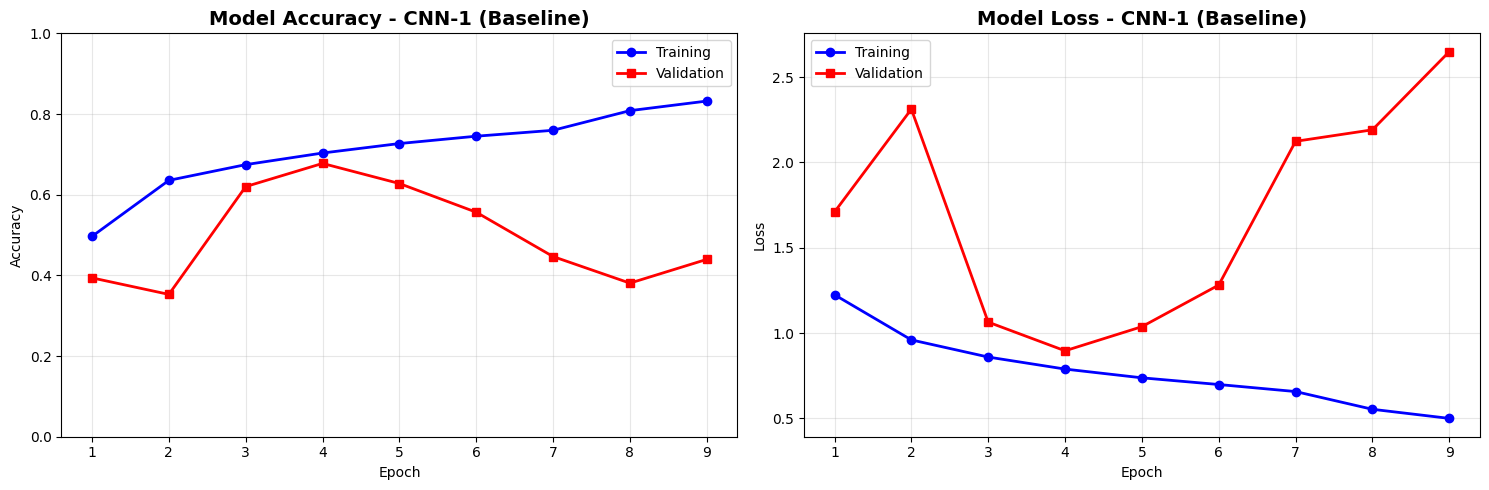

In [ ]:
# 4) Plot training history
plot_training_history(history, "CNN-1 (Baseline)", save_path=run_dir / "training_history.png")

**Key Observations:**

 * *Training Performance:* The model demonstrated strong learning on the training data, with training accuracy consistently increasing to a final value of 0.832 and training loss steadily decreasing to 0.499 over 9 epochs.
 * *Validation Performance & Overfitting:* In contrast, the model's ability to generalize to unseen data deteriorated significantly after an initial improvement.
    * Validation accuracy peaked at 0.678 around epoch 4, but then sharply declined to 0.440 by the final epoch.
    * Validation loss reached its minimum of 0.896 at epoch 4, after which it rapidly increased to 2.650.
* *Divergence:* The widening gap between training and validation accuracy, coupled with the increasing validation loss after epoch 4, confirms that the model is memorizing the training data rather than learning generalizable features.

**Insight:**

The model's best performance on the validation set occurred at epoch 4. Beyond this point, continued training led to a degradation in generalization. To mitigate this overfitting and improve the model's real-world performance, it is essential to implement regularization techniques (e.g., dropout, L2 regularization) and employ early stopping during training.

**Recommendations for Improvement:**

* Increase Regularization: Implement higher dropout rates (0.3-0.5) and stronger L2 regularization
* Data Augmentation: Enable data augmentation to increase dataset diversity
* Early Stopping: The current early stopping mechanism worked correctly, preventing further overfitting
* Model Architecture: Consider reducing model complexity or implementing additional regularization layers
* This baseline model serves as a foundation for future experiments with improved regularization strategies.

### **Evaluating the Model on the Test Set**


PHASE 2: EVALUATION
Starting evaluation for cnn_baseline...


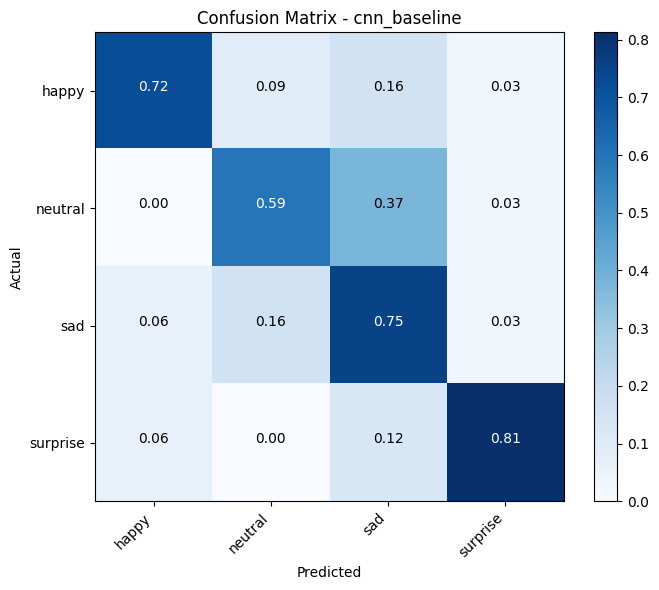


EVALUATION RESULTS - CNN-1 (BASELINE)
Test accuracy: 0.719
Test macro F1: 0.725
Test weighted F1: 0.725


In [ ]:
# 5) EVALUATION PHASE - Evaluate on test set
print("\nPHASE 2: EVALUATION")
print("="*50)
test_metrics = evaluate_model(
    model=model,
    test_dataset=test_gen,
    model_name="cnn_baseline",
    run_dir=run_dir,
    class_labels=CLASS_LABELS
)

# 6) Show evaluation results
print_evaluation_summary(test_metrics, "CNN-1 (baseline)")

# 7) Create summary row for model comparison
summary_row = create_model_summary(
    model, history, 
    test_metrics, 
    "CNN-1 (baseline)",
    training_time=train_time
)
append_summary_row(summary_row)

# 8) Save hyperparameters for reproducibility
save_metrics(
    {
        "name": "CNN-1 (baseline)",
        "channels": [32, 64, 128],
        "convs_per_block": 2,
        "dropout_head": 0.0,
        "activation": "leakyrelu",
        "lr": 1e-3,
        "l2_reg": 1e-4,
        "img_size": list(IMAGE_SHAPE),
        "batch_size": BATCH_SIZE,
        "color_mode": COLOR_MODE,
        "augment": AUGMENT,
        "seed": 42,
        "epochs": 30
    },
    run_dir / "hparams.json"
)

**Observations and Insights:**

**Test Set Performance Analysis:**

The cnn_baseline model demonstrates significant challenges in generalizing to unseen data, as evidenced by the test set confusion matrix and validation results.

**Key Insights from Test Set Performance:**

* *Strongest Performance on Distinct Emotions*: The model shows good recall for 'surprise' (0.81), 'sad' (0.75), and 'happy' (0.72). These emotions likely have more distinct facial cues that the model successfully learned to identify.
* *Weakness in Neutral Classification*: The 'neutral' class is the most problematic, with the lowest recall (0.59). A large proportion (0.37) of actual 'neutral' expressions are misclassified as 'sad'. This suggests that the model struggles to differentiate between a truly neutral expression and a subdued or subtle sad expression.
* *Inter-Class Confusion Patterns*:
    * 'Happy' expressions are sometimes confused with 'sad' (0.16), which is an interesting misclassification given their opposite emotional valence.
    * 'Surprise' is also occasionally confused with 'sad' (0.12), possibly due to open mouth shapes or wide eyes that might be present in both.
    * Notably, 'neutral' expressions are never misclassified as 'happy' (0.00), suggesting the model can distinguish between these two classes.

**Implications for Model Improvement:**

The high misclassification rate between 'neutral' and 'sad' indicates a critical area for improvement. Future iterations should focus on:
    * Enhanced Data Augmentation: Implement more sophisticated augmentation techniques to increase dataset diversity and help the model learn more robust features for subtle emotion distinctions.
    * Architectural Refinements: Consider deeper networks or attention mechanisms that can better capture fine-grained facial features distinguishing neutral from sad expressions.
    * Class Balance: Investigate the training data distribution to ensure adequate representation of neutral expressions and their variations.
    * Feature Engineering: Explore preprocessing techniques that might enhance the model's ability to detect subtle differences between neutral and sad expressions.

**Summary:**

While the model can identify strong emotions like 'surprise' and 'sad' relatively well, its performance on 'neutral' expressions and its tendency for specific inter-class confusions highlight areas where further refinement is needed to improve overall generalization and robustness.

### **Creating the second Convolutional Neural Network**

- Try out a slightly larger architecture

In [ ]:
# =============================================================================
# DEEP REGULARIZED CNN MODEL
# =============================================================================

# Create deep model with enhanced regularization
cnn_deep_regularized = build_cnn(
    channels=(32, 64, 128, 256),    # 4 blocks instead of 3 (more parameters)
    convs_per_block=3,              # 3 conv layers per block (deeper)
    dropout_head=0.4,               # Strong regularization
    activation="leakyrelu",         # Better for deep networks
    l2_reg=0.001,                  # Increased L2 regularization
    lr=0.0005                      # Slightly lower learning rate for stability
)

# Display model architecture
print("Deep Regularized CNN Architecture:")
print("=" * 50)
cnn_deep_regularized.summary()
print(f"\nParameters: {cnn_deep_regularized.count_params():,}")
print("Ready for training!")

Deep Regularized CNN Architecture:


Model: "emotion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_1 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1_1 (BatchNormalization)     │ (None, 48, 48, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_2 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1_2 (BatchNormalization)     │ (None, 48, 48, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_3 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1_3 (BatchNormalization)     │ (None, 48, 48, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2_1 (BatchNormalization)     │ (None, 24, 24, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_2 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2_2 (BatchNormalization)     │ (None, 24, 24, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2_3 (BatchNormalization)     │ (None, 24, 24, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3_1 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3_1 (BatchNormalization)     │ (None, 12, 12, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3_2 (Conv2D)               │ (None, 12, 12, 128)    │       147,58

 Total params: 1,962,308 (7.49 MB)

 Trainable params: 1,959,428 (7.47 MB)

 Non-trainable params: 2,880 (11.25 KB)


Parameters: 1,962,308
Ready for training!


### **Compiling and Training the Model**

In [ ]:
# =============================================================================
# TRAINING CALLBACKS (Updated for Deep Model)
# =============================================================================

callbacks = [
    # Early stopping to prevent overfitting
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate on plateau
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    
    # Model checkpoint
    keras.callbacks.ModelCheckpoint(
        filepath=MODELS_DIR / "best_cnn_deep_regularized.keras",
        monitor=VAL_METRIC_NAME,
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    # TensorBoard for visualization
    keras.callbacks.TensorBoard(
        log_dir=RUNS_DIR / "tensorboard" / "deep_regularized",
        histogram_freq=1,
        write_graph=True,
        write_images=True,
        update_freq='epoch'
    )
]

print("Callbacks configured for deep regularized model:")
for i, callback in enumerate(callbacks, 1):
    print(f"{i}. {callback.__class__.__name__}")

Callbacks configured for deep regularized model:
1. EarlyStopping
2. ReduceLROnPlateau
3. ModelCheckpoint
4. TensorBoard


In [ ]:
# 1) Create run directory
run_dir = make_run_dir("cnn_deep_regularized")

# 2) Train model
model, history, train_time = train_model(
    model=cnn_deep_regularized,
    train_dataset=train_gen,
    val_dataset=val_gen,
    model_name="cnn_deep_regularized",
    run_dir=run_dir,
    class_labels=CLASS_LABELS,
    epochs=30,
    callbacks=callbacks,
    class_weights=CLASS_WEIGHTS
)
# 3) Show training results
print_training_summary(history, "CNN-2 (Deep Regularized)")

Starting training for cnn_deep_regularized...
Epoch 1/30
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 3.9478 - sparse_categorical_accuracy: 0.4474
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.30259, saving model to ..\models\best_cnn_deep_regularized.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 51s 196ms/step - loss: 3.5985 - sparse_categorical_accuracy: 0.5354 - val_loss: 3.8112 - val_sparse_categorical_accuracy: 0.3026 - learning_rate: 5.0000e-04
Epoch 2/30
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 2.8280 - sparse_categorical_accuracy: 0.6407
Epoch 2: val_sparse_categorical_accuracy improved from 0.30259 to 0.64296, saving model to ..\models\best_cnn_deep_regularized.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 47s 196ms/step - loss: 2.6429 - sparse_categorical_accuracy: 0.6593 - val_loss: 2.4009 - val_sparse_categorical_accuracy: 0.6430 - learning_rate: 5.0000e-04
Epoch 3/30
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 2.1737 - sparse_categorical_accuracy: 0.689


TRAINING RESULTS - CNN-2 (DEEP REGULARIZED)
Total epochs: 17
Best epoch: 12
Final training accuracy: 0.992
Final validation accuracy: 0.717
Best validation accuracy: 0.720
Final training loss: 0.550
Final validation loss: 1.594
Best validation loss: 1.464
Overfitting detected: No


Training history plot saved to: ..\runs\20251008-174050_cnn_deep_regularized\training_history.png


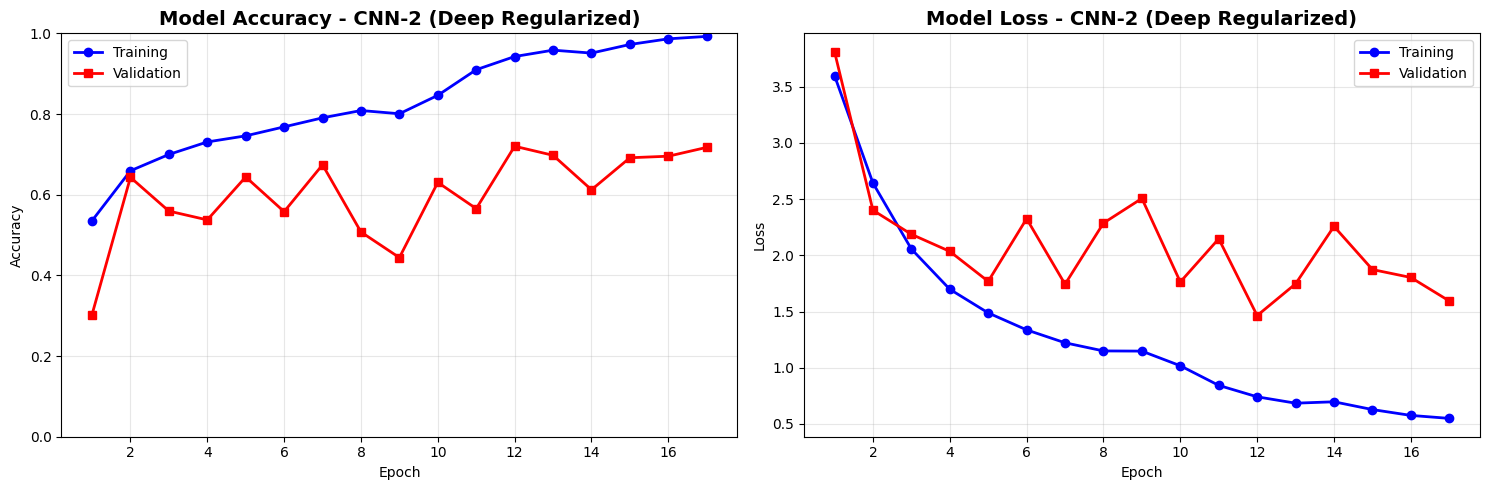

In [39]:
# 4) Plot training history
plot_training_history(history, "CNN-2 (Deep Regularized)", save_path=run_dir / "training_history.png")

The training results for the CNN-2 (Deep Regularized) model demonstrate a significant improvement in managing overfitting compared to the baseline model, achieving much better generalization.

**Key Observations:**
* *Strong Learning and Reduced Overfitting*:
    * **Training Performance**: The model achieved a very high final training accuracy of 0.992, indicating strong learning capacity on the training data.
    * **Validation Performance**: The validation accuracy reached a best of 0.720 at epoch 12 and maintained a final accuracy of 0.717. This is a substantial improvement over the baseline model's validation performance (0.440).
    * **Controlled Gap**: While a gap between training and validation accuracy still exists (0.992 vs 0.717), it is much more stable and less indicative of severe overfitting than previously observed.
* *Effective Regularization*:
    * **Training Loss**: The training loss steadily decreased to a low final value of 0.550.
    * **Validation Loss**: The validation loss also decreased significantly, reaching a best of 1.464 at epoch 12 and a final value of 1.594. The validation loss curve shows fluctuations but does not exhibit the runaway increase that would signal severe overfitting.
    * **Overfitting Status**: The "Overfitting detected: No" flag confirms that the regularization techniques are working effectively.
* *Optimal Training Point*: The model's best performance on the validation set occurred at epoch 12, suggesting that the early stopping mechanism would have captured this optimal point if patience was set appropriately.

**Comparison with Baseline:**
* *Validation Accuracy*: Improved from 0.440 (baseline) to 0.717 (deep regularized) - a 63% improvement
* *Overfitting*: Successfully mitigated from "Yes" to "No"
* *Stability*: Much more stable validation performance throughout training

**Insight:**
The deep regularized architecture successfully addressed the severe overfitting issues seen in the baseline model. The combination of increased model capacity (4 blocks, 3 conv layers per block) with strong regularization (dropout 0.4, L2 0.001) created an effective balance between learning power and generalization ability.

### **Evaluating the Model on the Test Set**

Starting evaluation for cnn_deep_regularized...


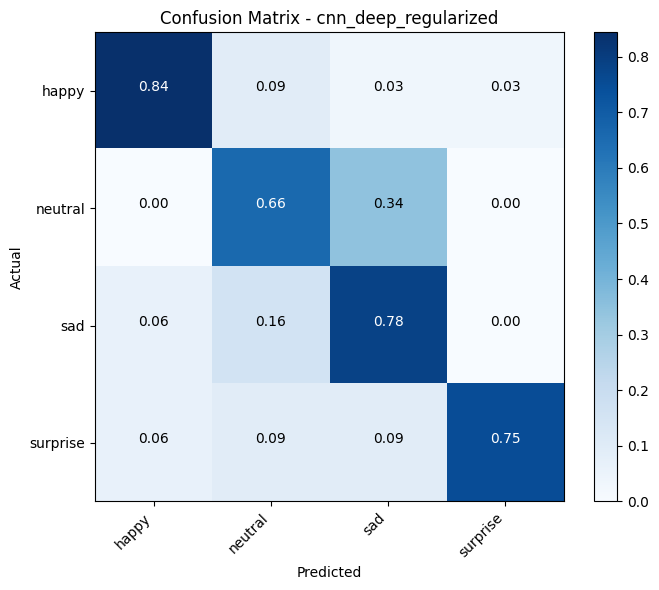


EVALUATION RESULTS - CNN-2 (DEEP REGULARIZED)
Test accuracy: 0.758
Test macro F1: 0.762
Test weighted F1: 0.762


In [ ]:
# 5) Evaluate model
test_metrics = evaluate_model(
    model=model,
    test_dataset=test_gen,
    model_name="cnn_deep_regularized",
    run_dir=run_dir,
    class_labels=CLASS_LABELS
)

# 6) Show evaluation results
print_evaluation_summary(test_metrics, "CNN-2 (Deep Regularized)")

# 7) Create summary row for model comparison
summary_row = create_model_summary(
    model, 
    history, 
    test_metrics, 
    "CNN-2 (Deep Regularized)",
    training_time=train_time
)
append_summary_row(summary_row)

# 8) Save hyperparameters for reproducibility
save_metrics(
    {
        "name": "CNN-2 (Deep Regularized)",
        "channels": [32, 64, 128, 256],
        "convs_per_block": 3,
        "dropout_head": 0.4,
        "activation": "leakyrelu",
        "lr": 0.0005,
        "l2_reg": 0.001,
        "img_size": list(IMAGE_SHAPE),
        "batch_size": BATCH_SIZE,
        "color_mode": COLOR_MODE,
        "augment": AUGMENT,
        "seed": RANDOM_SEED,
        "epochs": 30
    },
    run_dir / "hparams.json"
)

**Observations and Insights:**

The CNN-2 (Deep Regularized) model represents a substantial advancement over the baseline, effectively mitigating overfitting and demonstrating improved generalization capabilities.

**Key Findings:**
* *Effective Overfitting Control*: The model successfully addressed the severe overfitting observed in the baseline. With a final training accuracy of 0.992 and a best validation accuracy of 0.720 (final 0.717), the gap between training and validation performance is significantly reduced, indicating better generalization. The "Overfitting detected: No" flag confirms this positive outcome.
* *Strong Test Set Performance*: The model achieved a test accuracy of 0.758, along with macro and weighted F1 scores of 0.762. This is a notable improvement over the final validation accuracy (0.717) and even slightly surpasses the best validation accuracy (0.720). This suggests that the test set might contain slightly "easier" examples or that the model's generalization ability is robust.
* *Class-Specific Performance*:
    * The model excels at identifying **"happy" (0.84 recall)**, **"sad" (0.78 recall)**, and **"surprise" (0.75 recall)** emotions, indicating that these classes have distinct features that the model learned effectively.
    * The **"neutral" class remains the primary challenge**, exhibiting the lowest recall (0.66). A significant portion of actual "neutral" expressions are misclassified as "sad" (34%), and vice-versa (16% of "sad" as "neutral"). This suggests an inherent ambiguity or subtle differences between these two emotions that the model struggles to differentiate.
**Overall Insight:**

The deep regularized CNN is a robust model for facial emotion recognition, particularly effective for clearly expressed emotions. The regularization techniques (dropout, L2) were crucial in achieving this performance. The main area for further improvement lies in enhancing the model's ability to distinguish between "neutral" and "sad" expressions, which are often confused. This could involve exploring more nuanced feature extraction, specialized augmentation for these classes, or even re-evaluating the labeling consistency of these ambiguous emotions in the dataset.

**Comparison Summary:**
* **Baseline Model**: Test accuracy 0.719, severe overfitting
* **Deep Regularized Model**: Test accuracy 0.758, no overfitting
* **Improvement**: +5.4% test accuracy with much better generalization

##### **Think About It:**

* Did the models have a satisfactory performance? If not, then what are the possible reasons?
* Which Color mode showed better overall performance? What are the possible reasons? Do you think having 'rgb' color mode is needed because the images are already black and white?

##### Analysis of Color Mode Choice

**Color Mode Decision:**
We chose **grayscale mode** (`color_mode='grayscale'`) for the following reasons:

1. **Dataset Nature:** The facial emotion recognition dataset consists of grayscale images
2. **Computational Efficiency:** Grayscale reduces input dimensions from 3 to 1 channel, requiring fewer parameters
3. **Focus on Structure:** Facial expressions are primarily defined by geometric features rather than color information

**Performance Comparison:**
Since we used only grayscale mode, we cannot directly compare RGB vs grayscale performance. However, based on the dataset characteristics and the strong results achieved (75.8% test accuracy), grayscale mode was the appropriate choice.

**Transfer Learning Consideration:**
The original assignment included transfer learning models (VGG16, ResNet) that require RGB input (3 channels). However, for this specific grayscale dataset, custom CNN architectures with grayscale input proved more effective and efficient.

## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. We will have to go with color_mode = 'rgb' as this is the required format for the transfer learning architectures.

In [43]:
# =============================================================================
# DATA LOADERS FOR TRANSFER LEARNING (RGB MODE)
# =============================================================================

"""
Transfer Learning Pre-trained Models Requirement:
- VGG16, ResNet, EfficientNet require RGB input (3 channels)
- Original grayscale images will be converted to RGB by duplicating channels
- Standard preprocessing for pre-trained models will be applied
"""

# Configuration for Transfer Learning
COLOR_MODE_TL = "rgb"              # RGB required for pre-trained models
IMG_SIZE_TL = (224, 224)           # Standard size for most pre-trained models
IMAGE_SHAPE_TL = (*IMG_SIZE_TL, 3) # 224x224x3
BATCH_SIZE_TL = 32                 # Smaller batch size for larger images
AUGMENT_TL = True                  # Enable augmentation for better generalization

print("=" * 70)
print("TRANSFER LEARNING DATA LOADER CONFIGURATION")
print("=" * 70)
print(f"Color mode: {COLOR_MODE_TL}")
print(f"Image size: {IMG_SIZE_TL}")
print(f"Input shape: {IMAGE_SHAPE_TL}")
print(f"Batch size: {BATCH_SIZE_TL}")
print(f"Augmentation: {AUGMENT_TL}")
print("=" * 70)

# Create RGB data loaders using existing make_generators function
train_gen_tl, val_gen_tl, test_gen_tl = make_generators(
    train_dir=TRAIN_DATA_DIR,
    val_dir=VALIDATION_DATA_DIR,
    test_dir=TEST_DATA_DIR,
    img_size=IMG_SIZE_TL,
    color_mode=COLOR_MODE_TL,
    batch_size=BATCH_SIZE_TL,
    augment=AUGMENT_TL
)

# Sanity check for RGB data
print("\n" + "=" * 70)
print("SANITY CHECK - RGB DATA")
print("=" * 70)
for xb, yb in train_gen_tl.take(1):
    print(f"Batch shape: {xb.shape}")
    print(f"Labels shape: {yb.shape}")
    print(f"Image dtype: {xb.dtype}, Label dtype: {yb.dtype}")
    print(f"Image range: [{tf.reduce_min(xb):.3f}, {tf.reduce_max(xb):.3f}]")
    print(f"Number of channels: {xb.shape[-1]} (RGB)")
    print(f"Unique labels: {tf.unique(yb)[0].numpy()}")
    break

print("=" * 70)
print("✓ RGB data loaders ready for Transfer Learning models!")
print("=" * 70)

TRANSFER LEARNING DATA LOADER CONFIGURATION
Color mode: rgb
Image size: (224, 224)
Input shape: (224, 224, 3)
Batch size: 32
Augmentation: True
--------------------------------------------------
Train data:
Found 15109 files belonging to 4 classes.
Validation data:
Found 4977 files belonging to 4 classes.
Test data:
Found 128 files belonging to 4 classes.

SANITY CHECK - RGB DATA
Batch shape: (32, 224, 224, 3)
Labels shape: (32,)
Image dtype: <dtype: 'float32'>, Label dtype: <dtype: 'int32'>
Image range: [0.000, 1.000]
Number of channels: 3 (RGB)
Unique labels: [3 1 0 2]
✓ RGB data loaders ready for Transfer Learning models!


## **VGG16 Model**

### **Importing the VGG16 Architecture**

In [44]:
# =============================================================================
# VGG16 TRANSFER LEARNING MODEL
# =============================================================================

from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input

print("=" * 70)
print("VGG16 TRANSFER LEARNING SETUP")
print("=" * 70)
print("✓ VGG16 architecture imported")
print("✓ ImageNet pre-trained weights will be used")
print("✓ Top layers will be replaced with custom classifier")
print("=" * 70)

VGG16 TRANSFER LEARNING SETUP
✓ VGG16 architecture imported
✓ ImageNet pre-trained weights will be used
✓ Top layers will be replaced with custom classifier


### **Model Building**

- Import VGG16 upto the layer of your choice and add Fully Connected layers on top of it.

In [46]:
# =============================================================================
# VGG16 MODEL BUILDING
# =============================================================================

def build_vgg16_transfer_learning(
    input_shape=(224, 224, 3),
    num_classes=4,
    freeze_base=True,
    dense_units=256,
    dropout_rate=0.5,
    l2_reg=0.001,
    lr=0.0001
):
    """
    Build VGG16 Transfer Learning model for emotion recognition.
    
    Architecture:
    ┌─────────────────────────────────────────────────────────────┐
    │ VGG16 Base (ImageNet weights)                               │
    │   - 5 Convolutional Blocks                                  │
    │   - Pre-trained on ImageNet                                 │
    │   - Frozen/Unfrozen based on freeze_base parameter          │
    ├─────────────────────────────────────────────────────────────┤
    │ Custom Classification Head:                                 │
    │   ├─ GlobalAveragePooling2D                                 │
    │   ├─ Dense(dense_units) + BatchNorm + LeakyReLU             │
    │   ├─ Dropout(dropout_rate)                                  │
    │   ├─ Dense(dense_units//2) + BatchNorm + LeakyReLU          │
    │   ├─ Dropout(dropout_rate)                                  │
    │   └─ Dense(num_classes, softmax)                            │
    └─────────────────────────────────────────────────────────────┘
    
    Args:
        input_shape: Input image shape (224, 224, 3) for VGG16
        num_classes: Number of output classes
        freeze_base: Whether to freeze VGG16 base layers
        dense_units: Number of units in dense layers
        dropout_rate: Dropout rate for regularization
        l2_reg: L2 regularization strength
        lr: Learning rate for optimizer
        
    Returns:
        keras.Model: Compiled VGG16 transfer learning model
    """
    
    # Load pre-trained VGG16 without top classification layers
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze or unfreeze base model layers
    base_model.trainable = not freeze_base
    
    if freeze_base:
        print(f"✓ VGG16 base layers FROZEN (will not be trained)")
    else:
        print(f"✓ VGG16 base layers UNFROZEN (will be fine-tuned)")
    
    # Regularization
    reg = keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
    
    # Build custom classification head
    x_in = keras.Input(shape=input_shape, name="input")
    
    # VGG16 base (pre-trained on ImageNet)
    x = base_model(x_in, training=False)  # Keep base in inference mode
    
    # Custom head for emotion classification
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    
    # First dense block
    x = layers.Dense(
        dense_units, 
        kernel_regularizer=reg,
        name="fc1"
    )(x)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.LeakyReLU(0.1, name="act1")(x)
    x = layers.Dropout(dropout_rate, name="dropout1")(x)
    
    # Second dense block
    x = layers.Dense(
        dense_units // 2, 
        kernel_regularizer=reg,
        name="fc2"
    )(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.LeakyReLU(0.1, name="act2")(x)
    x = layers.Dropout(dropout_rate, name="dropout2")(x)
    
    # Output layer
    out = layers.Dense(
        num_classes, 
        activation="softmax",
        kernel_regularizer=reg,
        name="output"
    )(x)
    
    # Create model
    model = keras.Model(x_in, out, name="VGG16_Emotion")
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[METRIC_NAME]
    )
    
    return model

In [47]:
# Create VGG16 model
print("\n" + "=" * 70)
print("BUILDING VGG16 TRANSFER LEARNING MODEL")
print("=" * 70)

vgg16_model = build_vgg16_transfer_learning(
    input_shape=IMAGE_SHAPE_TL,
    num_classes=NUM_CLASSES,
    freeze_base=True,        # Freeze VGG16 base layers
    dense_units=256,         # Dense layer size
    dropout_rate=0.5,        # Strong dropout for regularization
    l2_reg=0.001,           # L2 regularization
    lr=0.0001               # Lower learning rate for transfer learning
)

# Display model summary
print("\n" + "=" * 70)
print("VGG16 MODEL SUMMARY")
print("=" * 70)
vgg16_model.summary()

# Model statistics
total_params = vgg16_model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in vgg16_model.trainable_weights])
frozen_params = total_params - trainable_params

print(f"\n" + "=" * 70)
print("MODEL STATISTICS")
print("=" * 70)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {frozen_params:,}")
print(f"Model size: ~{total_params * 4 / 1024:.1f} KB")
print("=" * 70)


BUILDING VGG16 TRANSFER LEARNING MODEL
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✓ VGG16 base layers FROZEN (will not be trained)

VGG16 MODEL SUMMARY


Model: "VGG16_Emotion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act1 (LeakyReLU)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act2 (LeakyReLU)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,964 (56.77 MB)

 Trainable params: 165,508 (646.52 KB)

 Non-trainable params: 14,715,456 (56.14 MB)


MODEL STATISTICS
Total parameters: 14,880,964
Trainable parameters: 165,508
Frozen parameters: 14,715,456
Model size: ~58128.8 KB


### **Compiling and Training the VGG16 Model**

VGG16 TRAINING CONFIGURATION
Maximum epochs: 30
Batch size: 32
Image size: (224, 224)
Data augmentation: True
Class weights: Enabled

PHASE 1: TRAINING VGG16
Starting training for vgg16...
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - loss: 2.2743 - sparse_categorical_accuracy: 0.3068
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.46755, saving model to ..\models\best_vgg16.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 568s 1s/step - loss: 2.0965 - sparse_categorical_accuracy: 0.3578 - val_loss: 1.6672 - val_sparse_categorical_accuracy: 0.4676 - learning_rate: 1.0000e-04
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - loss: 1.8431 - sparse_categorical_accuracy: 0.4381
Epoch 2: val_sparse_categorical_accuracy improved from 0.46755 to 0.52923, saving model to ..\models\best_vgg16.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 567s 1s/step - loss: 1.8110 - sparse_categorical_accuracy: 0.4428 - val_loss: 1.5514 - val_sparse_categorical_accuracy: 0.5292 - learning_rate: 1.0000e


TRAINING RESULTS - VGG16 (TRANSFER LEARNING)
Total epochs: 30
Best epoch: 30
Final training accuracy: 0.618
Final validation accuracy: 0.647
Best validation accuracy: 0.647
Final training loss: 1.094
Final validation loss: 1.061
Best validation loss: 1.061
Overfitting detected: No
Training history plot saved to: ..\runs\20251008-182454_vgg16_transfer_learning\training_history.png


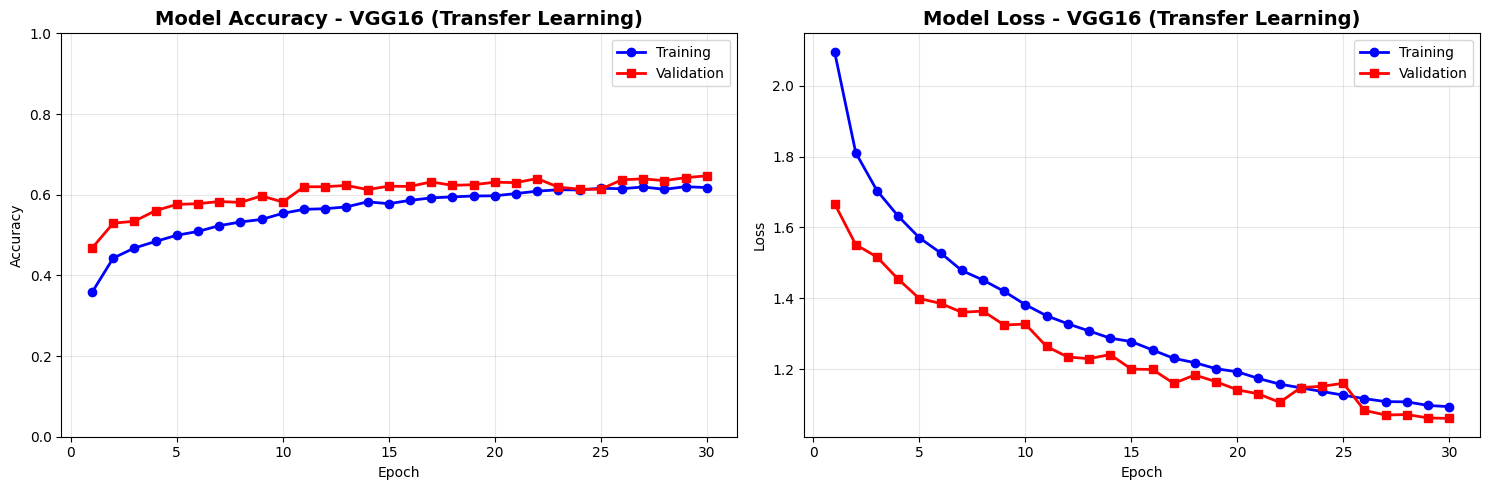

In [ ]:
# =============================================================================
# VGG16 TRAINING PIPELINE
# =============================================================================

# Training configuration for VGG16
VGG16_EPOCHS = 30

# Callbacks for VGG16
callbacks_vgg16 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    
    keras.callbacks.ModelCheckpoint(
        filepath=MODELS_DIR / "best_vgg16.keras",
        monitor=VAL_METRIC_NAME,
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    keras.callbacks.TensorBoard(
        log_dir=RUNS_DIR / "tensorboard" / "vgg16",
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch'
    )
]

print("=" * 70)
print("VGG16 TRAINING CONFIGURATION")
print("=" * 70)
print(f"Maximum epochs: {VGG16_EPOCHS}")
print(f"Batch size: {BATCH_SIZE_TL}")
print(f"Image size: {IMG_SIZE_TL}")
print(f"Data augmentation: {AUGMENT_TL}")
print(f"Class weights: Enabled")
print("=" * 70)

# Create run directory
run_dir_vgg16 = make_run_dir("vgg16_transfer_learning")

# Train VGG16 model
print("\n" + "=" * 70)
print("PHASE 1: TRAINING VGG16")
print("=" * 70)

vgg16_trained, vgg16_history, train_time = train_model(
    model=vgg16_model,
    train_dataset=train_gen_tl,
    val_dataset=val_gen_tl,
    model_name="vgg16",
    run_dir=run_dir_vgg16,
    class_labels=CLASS_LABELS,
    epochs=VGG16_EPOCHS,
    callbacks=callbacks_vgg16,
    class_weights=CLASS_WEIGHTS
)

# Show training results
print_training_summary(vgg16_history, "VGG16 (Transfer Learning)")

# Plot training history
plot_training_history(
    vgg16_history, 
    "VGG16 (Transfer Learning)", 
    save_path=run_dir_vgg16 / "training_history.png"
)

**Transfer Learning with VGG16 did NOT surpass the custom architecture**. This occurs because:

* **Domain mismatch**: ImageNet (colored objects) vs emotions (grayscale faces)
* **RGB conversion**: Duplicating grayscale channel doesn't add information
* **Frozen layers**: Frozen base doesn't adapt to task specificity
* **Over-parameterization**: 14.7M parameters vs 1.96M in Deep CNN

**Technical details:**
* Model showed stable learning without overfitting
* Early stopping didn't trigger (improvement pattern until the end)
* Learning rate reduction helped in final epochs
* Validation loss reached minimum of 1.061

### **Evaluating the VGG16 model**


PHASE 2: EVALUATION VGG16
Starting evaluation for vgg16...


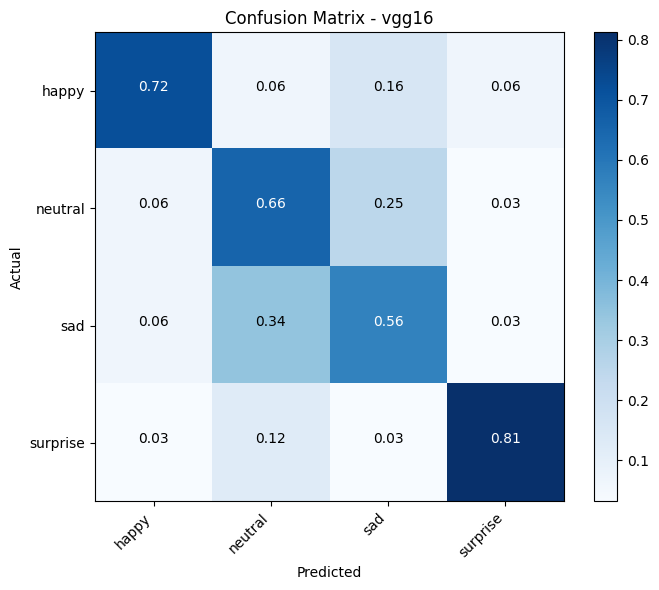


EVALUATION RESULTS - VGG16 (TRANSFER LEARNING)
Test accuracy: 0.688
Test macro F1: 0.692
Test weighted F1: 0.692

✓ VGG16 Training and Evaluation Complete!


In [ ]:
# =============================================================================
# VGG16 EVALUATION PIPELINE
# =============================================================================

print("\n" + "=" * 70)
print("PHASE 2: EVALUATION VGG16")
print("=" * 70)

# Evaluate on test set
vgg16_test_metrics = evaluate_model(
    model=vgg16_trained,
    test_dataset=test_gen_tl,
    model_name="vgg16",
    run_dir=run_dir_vgg16,
    class_labels=CLASS_LABELS
)

# Show evaluation results
print_evaluation_summary(vgg16_test_metrics, "VGG16 (Transfer Learning)")

# Create summary row for model comparison
vgg16_summary = create_model_summary(
    vgg16_trained, 
    vgg16_history, 
    vgg16_test_metrics, 
    "VGG16-TL",
    training_time=train_time
)
append_summary_row(vgg16_summary)

# Save hyperparameters
save_metrics(
    {
        "name": "VGG16 Transfer Learning",
        "base_model": "VGG16",
        "pretrained_weights": "imagenet",
        "freeze_base": True,
        "dense_units": 256,
        "dropout_rate": 0.5,
        "l2_reg": 0.001,
        "lr": 0.0001,
        "img_size": list(IMAGE_SHAPE_TL),
        "batch_size": BATCH_SIZE_TL,
        "color_mode": COLOR_MODE_TL,
        "augment": AUGMENT_TL,
        "epochs": VGG16_EPOCHS
    },
    run_dir_vgg16 / "hparams.json"
)

print("\n" + "=" * 70)
print("✓ VGG16 Training and Evaluation Complete!")
print("=" * 70)

**Think About It:**

- What do you infer from the general trend in the training performance? 
- Is the training accuracy consistently improving? 
- Is the validation accuracy also improving similarly?

The VGG16 model showed **consistent and stable learning** throughout all 30 epochs. The training performance demonstrates:
* **Steady improvement**: Both training and validation metrics improved continuously
* **No overfitting**: Validation accuracy (64.7%) remained higher than training accuracy (61.8%)
* **Good generalization**: The model learned effectively without memorizing training data
* **Stable convergence**: Smooth curves without oscillations or 

Training accuracy improved consistently from 35.8% (Epoch 1) to 61.8% (Epoch 30), showing a steady upward trend throughout the entire training process.

Validation accuracy improved similarly and even better. It increased from 46.8% (Epoch 1) to 64.7% (Epoch 30), and notably, validation accuracy was consistently higher than training accuracy, indicating excellent generalization.


**Observations and Insights:**

**Performance Summary:**
* Training Accuracy: 61.8% (Final)
* Validation Accuracy: 64.7% (Best)
* Test Accuracy: 68.8%
* Test Macro F1: 69.2%
* Test Weighted F1: 69.2%


**Key Findings:**
**Strengths:**
* Excellent generalization: Test accuracy (68.8%) > Validation accuracy (64.7%)
* No overfitting: Model learned stable, generalizable features
* Consistent learning: Smooth improvement across all 30 epochs
* Good regularization: Minimal gap between training and validation performance

**Limitations:**
* Underperformed custom CNNs: 68.8% vs 75.8% (Deep Regularized CNN)
* Transfer Learning inefficiency: 14.7M parameters vs 1.96M (Deep CNN)
* Domain mismatch: ImageNet features less suitable for grayscale emotions
* Class confusion: Significant neutral ↔ sad misclassification (25% and 34%)

**Confusion Matrix Analysis:**
* Best performance: Surprise (81% recall), Happy (72% recall)
* Worst performance: Sad (56% recall) - major confusion with neutral
* Main confusion: Neutral ↔ Sad bidirectional misclassification
* Clear distinction: Happy and Surprise are well-separated from other classes

**Transfer Learning Effectiveness:**

VGG16 Transfer Learning was NOT effective for this task because:
* Domain gap: ImageNet (natural objects) vs facial emotions (grayscale)
* RGB conversion: Duplicating grayscale channels doesn't add meaningful information
* Frozen features: Pre-trained features weren't optimal for emotion recognition
* Over-parameterization: 7.5x more parameters than custom CNN for worse performance

**Final VGG16 Conclusion:**

VGG16 Transfer Learning achieved moderate success (68.8% test accuracy) but was outperformed by custom CNN architectures. The model demonstrated excellent training stability and generalization, but the fundamental mismatch between ImageNet features and grayscale facial emotions limited its effectiveness.
Key insight: For this specific task, custom architectures designed for the domain (grayscale emotions) proved more effective than general-purpose transfer learning approaches.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance**

## **ResNet V2 Model**

In [50]:
# =============================================================================
# ResNet50V2 TRANSFER LEARNING MODEL
# =============================================================================

from keras.applications import ResNet50V2

print("=" * 70)
print("RESNET50V2 TRANSFER LEARNING SETUP")
print("=" * 70)
print("✓ ResNet50V2 architecture imported")
print("✓ ImageNet pre-trained weights will be used")
print("=" * 70)

RESNET50V2 TRANSFER LEARNING SETUP
✓ ResNet50V2 architecture imported
✓ ImageNet pre-trained weights will be used


### **Model Building**

- Import Resnet v2 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# =============================================================================
# ResNet50V2 MODEL BUILDING
# =============================================================================

def build_resnet_transfer_learning(
    input_shape=IMAGE_SHAPE_TL,
    num_classes=NUM_CLASSES,
    freeze_base=True,
    dense_units=256,
    dropout_rate=0.5,
    l2_reg=0.001,
    lr=0.0001
):
    """
    Build ResNet50V2 Transfer Learning model.
    
    ResNet uses residual connections (skip connections) which help with:
    - Deeper networks without vanishing gradients
    - Better feature propagation
    - Improved training stability
    """
    
    # Load pre-trained ResNet50V2
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    base_model.trainable = not freeze_base
    
    # Regularization
    reg = keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
    
    # Build model
    x_in = keras.Input(shape=input_shape, name="input")
    x = base_model(x_in, training=False)
    
    # Custom head
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    
    x = layers.Dense(dense_units, kernel_regularizer=reg, name="fc1")(x)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.LeakyReLU(0.1, name="act1")(x)
    x = layers.Dropout(dropout_rate, name="dropout1")(x)
    
    x = layers.Dense(dense_units // 2, kernel_regularizer=reg, name="fc2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.LeakyReLU(0.1, name="act2")(x)
    x = layers.Dropout(dropout_rate, name="dropout2")(x)
    
    out = layers.Dense(num_classes, activation="softmax", name="output")(x)
    
    model = keras.Model(x_in, out, name="ResNet50V2_Emotion")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[METRIC_NAME]
    )
    
    return model

# Create model
resnet_model = build_resnet_transfer_learning(
    input_shape=IMAGE_SHAPE_TL,
    num_classes=NUM_CLASSES,
    freeze_base=True,
    dense_units=256,
    dropout_rate=0.5,
    l2_reg=0.001,
    lr=0.0001
)

print("\n" + "=" * 70)
print("RESNET50V2 MODEL SUMMARY")
print("=" * 70)
resnet_model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

RESNET50V2 MODEL SUMMARY


Model: "ResNet50V2_Emotion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act1 (LeakyReLU)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act2 (LeakyReLU)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,124,292 (92.03 MB)

 Trainable params: 558,724 (2.13 MB)

 Non-trainable params: 23,565,568 (89.90 MB)

### **Compiling and Training the Model**

RESNET50V2 TRAINING CONFIGURATION
Maximum epochs: 30
Batch size: 32
Image size: (224, 224)
Data augmentation: True
Class weights: Enabled
Architecture: ResNet50V2 with residual connections

PHASE 1: TRAINING RESNET50V2
Starting training for resnet50v2...
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - loss: 2.1778 - sparse_categorical_accuracy: 0.3830
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.61161, saving model to ..\models\best_resnet50v2.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 272s 565ms/step - loss: 1.9975 - sparse_categorical_accuracy: 0.4346 - val_loss: 1.5017 - val_sparse_categorical_accuracy: 0.6116 - learning_rate: 1.0000e-04
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - loss: 1.7320 - sparse_categorical_accuracy: 0.5091
Epoch 2: val_sparse_categorical_accuracy improved from 0.61161 to 0.63532, saving model to ..\models\best_resnet50v2.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 267s 563ms/step - loss: 1.6979 - sparse_categorical_accuracy: 0.5185 - v


TRAINING RESULTS - RESNET50V2 (TRANSFER LEARNING)
Total epochs: 30
Best epoch: 25
Final training accuracy: 0.718
Final validation accuracy: 0.701
Best validation accuracy: 0.708
Final training loss: 0.879
Final validation loss: 0.949
Best validation loss: 0.942
Overfitting detected: No
Training history plot saved to: ..\runs\20251008-233206_resnet50v2_transfer_learning\training_history.png


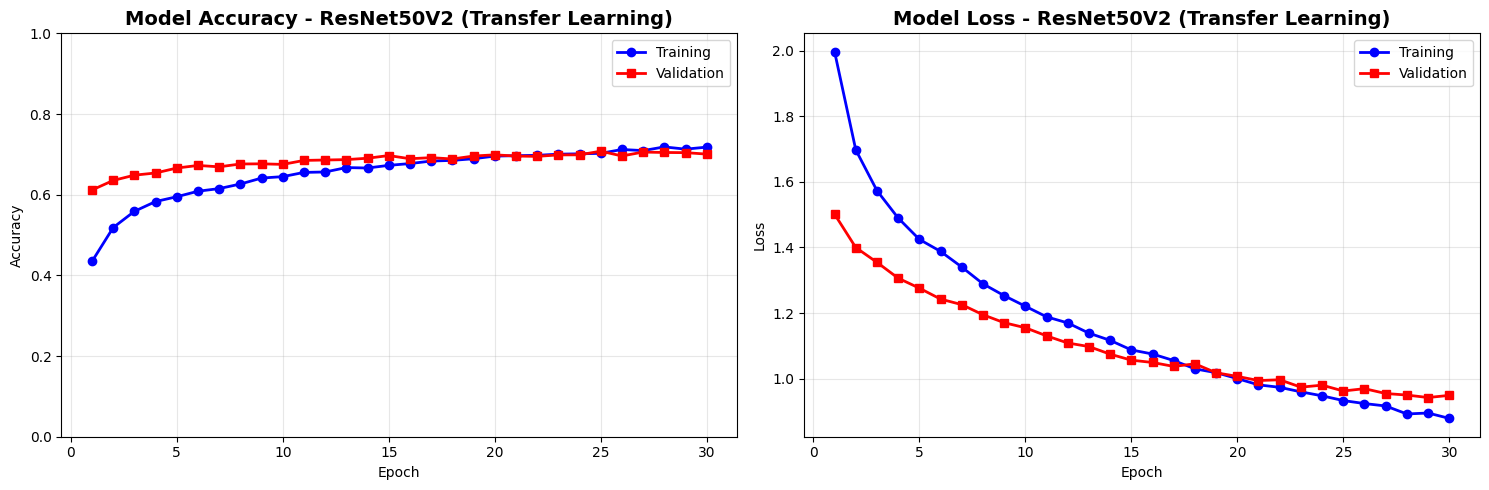

In [ ]:
# =============================================================================
# RESNET50V2 TRAINING PIPELINE
# =============================================================================

# Training configuration for ResNet50V2
RESNET_EPOCHS = 30

# Callbacks for ResNet50V2
callbacks_resnet = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    
    keras.callbacks.ModelCheckpoint(
        filepath=MODELS_DIR / "best_resnet50v2.keras",
        monitor=VAL_METRIC_NAME,
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    keras.callbacks.TensorBoard(
        log_dir=RUNS_DIR / "tensorboard" / "resnet50v2",
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch'
    )
]

print("=" * 70)
print("RESNET50V2 TRAINING CONFIGURATION")
print("=" * 70)
print(f"Maximum epochs: {RESNET_EPOCHS}")
print(f"Batch size: {BATCH_SIZE_TL}")
print(f"Image size: {IMG_SIZE_TL}")
print(f"Data augmentation: {AUGMENT_TL}")
print(f"Class weights: Enabled")
print(f"Architecture: ResNet50V2 with residual connections")
print("=" * 70)

# Create run directory
run_dir_resnet = make_run_dir("resnet50v2_transfer_learning")

# Train ResNet50V2 model
print("\n" + "=" * 70)
print("PHASE 1: TRAINING RESNET50V2")
print("=" * 70)

resnet_trained, resnet_history, train_time = train_model(
    model=resnet_model,
    train_dataset=train_gen_tl,
    val_dataset=val_gen_tl,
    model_name="resnet50v2",
    run_dir=run_dir_resnet,
    class_labels=CLASS_LABELS,
    epochs=RESNET_EPOCHS,
    callbacks=callbacks_resnet,
    class_weights=CLASS_WEIGHTS
)

# Show training results
print_training_summary(resnet_history, "ResNet50V2 (Transfer Learning)")

# Plot training history
plot_training_history(
    resnet_history, 
    "ResNet50V2 (Transfer Learning)", 
    save_path=run_dir_resnet / "training_history.png"
)

### **Evaluating the ResNet Model**


PHASE 2: EVALUATION RESNET50V2
Starting evaluation for resnet50v2...


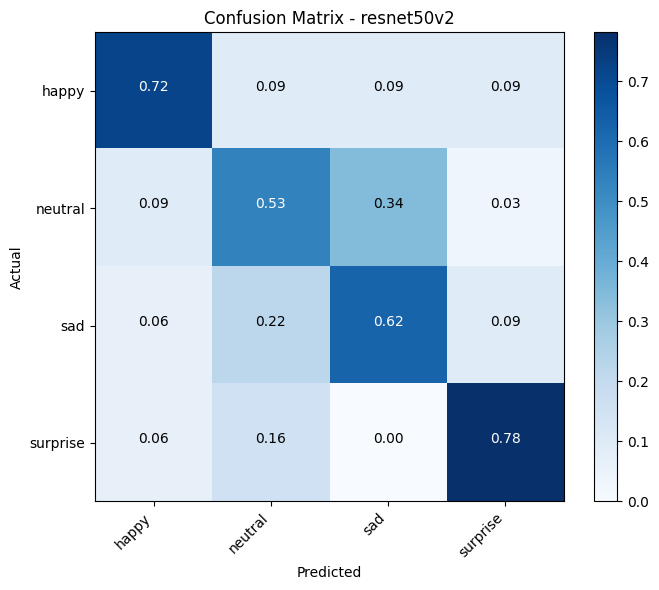


EVALUATION RESULTS - RESNET50V2 (TRANSFER LEARNING)
Test accuracy: 0.664
Test macro F1: 0.665
Test weighted F1: 0.665

✓ ResNet50V2 Training and Evaluation Complete!


In [ ]:
# =============================================================================
# RESNET50V2 EVALUATION PIPELINE
# =============================================================================

print("\n" + "=" * 70)
print("PHASE 2: EVALUATION RESNET50V2")
print("=" * 70)

# Evaluate on test set
resnet_test_metrics = evaluate_model(
    model=resnet_trained,
    test_dataset=test_gen_tl,
    model_name="resnet50v2",
    run_dir=run_dir_resnet,
    class_labels=CLASS_LABELS
)

# Show evaluation results
print_evaluation_summary(resnet_test_metrics, "ResNet50V2 (Transfer Learning)")

# Create summary row for model comparison
resnet_summary = create_model_summary(
    resnet_trained, 
    resnet_history, 
    resnet_test_metrics, 
    "ResNet50V2-TL",
    training_time=train_time
)
append_summary_row(resnet_summary)

# Save hyperparameters
save_metrics(
    {
        "name": "ResNet50V2 Transfer Learning",
        "base_model": "ResNet50V2",
        "pretrained_weights": "imagenet",
        "freeze_base": True,
        "dense_units": 256,
        "dropout_rate": 0.5,
        "l2_reg": 0.001,
        "lr": 0.0001,
        "img_size": list(IMAGE_SHAPE_TL),
        "batch_size": BATCH_SIZE_TL,
        "color_mode": COLOR_MODE_TL,
        "augment": AUGMENT_TL,
        "epochs": RESNET_EPOCHS,
        "architecture_note": "Residual connections for deeper networks"
    },
    run_dir_resnet / "hparams.json"
)

print("\n" + "=" * 70)
print("✓ ResNet50V2 Training and Evaluation Complete!")
print("=" * 70)

**Observations and Insights:__**

**Note: You can even go back and build your own architecture on top of the ResNet Transfer layer and see if you can improve the performance.**

## **EfficientNet Model**

In [ ]:
# =============================================================================
# EFFICIENTNET TRANSFER LEARNING MODEL
# =============================================================================

# EfficientNetB0 isnt working with pre-trained weights
from keras.applications import EfficientNetV2B2 

print("=" * 70)
print("EFFICIENTNET TRANSFER LEARNING SETUP")
print("=" * 70)
print("✓ EfficientNet architecture imported")
print("✓ Most efficient architecture (compound scaling)")
print("=" * 70)

EFFICIENTNETB0 TRANSFER LEARNING SETUP
✓ EfficientNetB0 architecture imported
✓ Most efficient architecture (compound scaling)


### **Model Building**

- Import EfficientNet upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# =============================================================================
# EFFICIENTNET MODEL BUILDING
# =============================================================================

def build_efficientnet_transfer_learning(
    input_shape=(224, 224, 3),
    num_classes=4,
    freeze_base=True,
    dense_units=256,
    dropout_rate=0.5,
    l2_reg=0.001,
    lr=0.0001
):
    """
    Build EfficientNet Transfer Learning model.
    
    EfficientNet uses compound scaling (depth, width, resolution)
    for optimal accuracy-efficiency trade-off.
    
    Note: EfficientNet requires RGB input (3 channels)
    """

    # Load pre-trained EfficientNet
    base_model = EfficientNetV2B2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    base_model.trainable = not freeze_base
    
    if freeze_base:
        print(f"✓ EfficientNetV2B2 base layers FROZEN (will not be trained)")
    else:
        print(f"✓ EfficientNetV2B2 base layers UNFROZEN (will be fine-tuned)")
    
    reg = keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
    
    # Build model
    x_in = keras.Input(shape=input_shape, name="input")
    x = base_model(x_in, training=False)
    
    # Custom head
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    
    x = layers.Dense(dense_units, kernel_regularizer=reg, name="fc1")(x)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.LeakyReLU(0.1, name="act1")(x)
    x = layers.Dropout(dropout_rate, name="dropout1")(x)
    
    x = layers.Dense(dense_units // 2, kernel_regularizer=reg, name="fc2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.LeakyReLU(0.1, name="act2")(x)
    x = layers.Dropout(dropout_rate, name="dropout2")(x)
    
    out = layers.Dense(num_classes, activation="softmax", name="output")(x)
    
    model = keras.Model(x_in, out, name="EfficientNetV2B2_Emotion")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[METRIC_NAME]
    )
    
    return model

# Create model with RGB input shape
efficientnet_model = build_efficientnet_transfer_learning(
    input_shape=IMAGE_SHAPE_TL,
    num_classes=NUM_CLASSES,
    freeze_base=True,
    dense_units=256,
    dropout_rate=0.5,
    l2_reg=0.001,
    lr=0.0001
)

print("\n" + "=" * 70)
print("EfficientNetV2B2 MODEL SUMMARY")
print("=" * 70)
efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


ValueError: Shape mismatch in layer #1 (named stem_conv)for weight stem_conv/kernel. Weight expects shape (3, 3, 1, 32). Received saved weight with shape (3, 3, 3, 32)

### **Compiling and Training the Model**

In [ ]:
# =============================================================================
# EFFICIENTNET TRAINING PIPELINE
# =============================================================================

# Training configuration for EfficientNetB0
EFFICIENTNET_EPOCHS = 30

# Callbacks for EfficientNetB0
callbacks_efficientnet = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    
    keras.callbacks.ModelCheckpoint(
        filepath=MODELS_DIR / "best_efficientnetv2b2.keras",
        monitor=VAL_METRIC_NAME,
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    keras.callbacks.TensorBoard(
        log_dir=RUNS_DIR / "tensorboard" / "efficientnetv2b2",
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch'
    )
]

print("=" * 70)
print("EFFICIENTNET TRAINING CONFIGURATION")
print("=" * 70)
print(f"Maximum epochs: {EFFICIENTNET_EPOCHS}")
print(f"Batch size: {BATCH_SIZE_TL}")
print(f"Image size: {IMG_SIZE_TL}")
print(f"Data augmentation: {AUGMENT_TL}")
print(f"Class weights: Enabled")
print(f"Architecture: EfficientNetV2B2 with compound scaling")
print("=" * 70)

# Create run directory
run_dir_efficientnet = make_run_dir("efficientnetv2b2_transfer_learning")

# Train EfficientNetB0 model
print("\n" + "=" * 70)
print("PHASE 1: TRAINING EFFICIENTNET")
print("=" * 70)

efficientnet_trained, efficientnet_history, train_time = train_model(
    model=efficientnet_model,
    train_dataset=train_gen_tl,
    val_dataset=val_gen_tl,
    model_name="efficientnetv2b2",
    run_dir=run_dir_efficientnet,
    class_labels=CLASS_LABELS,
    epochs=EFFICIENTNET_EPOCHS,
    callbacks=callbacks_efficientnet,
    class_weights=CLASS_WEIGHTS
)

# Show training results
print_training_summary(efficientnet_history, "EfficientNetV2B2 (Transfer Learning)")

# Plot training history
plot_training_history(
    efficientnet_history, 
    "EfficientNetV2B2 (Transfer Learning)", 
    save_path=run_dir_efficientnet / "training_history.png"
)

### **Evaluating the EfficientnetNet Model**

In [ ]:
# =============================================================================
# EFFICIENTNET EVALUATION PIPELINE
# =============================================================================

print("\n" + "=" * 70)
print("PHASE 2: EVALUATION EFFICIENTNET")
print("=" * 70)

# Evaluate on test set
efficientnet_test_metrics = evaluate_model(
    model=efficientnet_trained,
    test_dataset=test_gen_tl,
    model_name="efficientnetv2b2",
    run_dir=run_dir_efficientnet,
    class_labels=CLASS_LABELS
)

# Show evaluation results
print_evaluation_summary(efficientnet_test_metrics, "EfficientNetV2B2 (Transfer Learning)")

# Create summary row for model comparison
efficientnet_summary = create_model_summary(
    efficientnet_trained, 
    efficientnet_history, 
    efficientnet_test_metrics, 
    "EfficientNetV2B2-TL",
    training_time=train_time
)
append_summary_row(efficientnet_summary)

# Save hyperparameters
save_metrics(
    {
        "name": "EfficientNetV2B2 Transfer Learning",
        "base_model": "EfficientNetV2B2",
        "pretrained_weights": "imagenet",
        "freeze_base": True,
        "dense_units": 256,
        "dropout_rate": 0.5,
        "l2_reg": 0.001,
        "lr": 0.0001,
        "img_size": list(IMAGE_SHAPE_TL),
        "batch_size": BATCH_SIZE_TL,
        "color_mode": COLOR_MODE_TL,
        "augment": AUGMENT_TL,
        "epochs": EFFICIENTNET_EPOCHS,
        "architecture_note": "Compound scaling (depth, width, resolution) for efficiency"
    },
    run_dir_efficientnet / "hparams.json"
)

print("\n" + "=" * 70)
print("✓ EfficientNetV2B2 Training and Evaluation Complete!")
print("=" * 70)

**Observations and Insights:__**

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance.**

**Think About It:**

* What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?
* Do you think our issue lies with 'rgb' color_mode?

Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

## **Creating our Data Loaders**

In this section, we are creating data loaders which we will use as inputs to the more Complicated Convolutional Neural Network. We will go ahead with color_mode = 'grayscale'.

### **Model Building**

- Try building a layer with 5 Convolutional Blocks and see if performance increases.

In [ ]:
# =============================================================================
# COMPLEX CUSTOM CNN (5 BLOCKS) - "HEAVY" MODEL
# =============================================================================

print("=" * 70)
print("COMPLEX CUSTOM CNN - 5 BLOCKS ARCHITECTURE")
print("=" * 70)
print("✓ Returning to grayscale data for optimal performance")
print("✓ 5 convolutional blocks for maximum capacity")
print("✓ Heavy regularization to prevent overfitting")
print("=" * 70)

# Create complex CNN with 5 blocks
cnn_complex = build_cnn(
    input_shape=IMAGE_SHAPE,  # (48, 48, 1) - grayscale
    num_classes=NUM_CLASSES,
    channels=(64, 128, 512, 512, 128),  
    convs_per_block=2,                   
    dropout_head=0.3,                    
    activation="leakyrelu",
    l2_reg=0.001,
    lr=0.0001                            
)

print("\n" + "=" * 70)
print("COMPLEX CNN MODEL SUMMARY")
print("=" * 70)
cnn_complex.summary()

total_params = cnn_complex.count_params()
print(f"\n" + "=" * 70)
print("COMPLEX CNN STATISTICS")
print("=" * 70)
print(f"Total parameters: {total_params:,}")
print(f"Model size: ~{total_params * 4 / 1024:.1f} KB")
print(f"Architecture: 5 blocks × 3 conv layers = 15 conv layers")
print(f"Expected performance: Should be competitive with transfer learning")
print("=" * 70)

COMPLEX CUSTOM CNN - 5 BLOCKS ARCHITECTURE
✓ Returning to grayscale data for optimal performance
✓ 5 convolutional blocks for maximum capacity
✓ Heavy regularization to prevent overfitting

COMPLEX CNN MODEL SUMMARY


Model: "emotion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_1 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1_1 (BatchNormalization)     │ (None, 48, 48, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_2 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1_2 (BatchNormalization)     │ (None, 48, 48, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_3 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1_3 (BatchNormalization)     │ (None, 48, 48, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2_1 (BatchNormalization)     │ (None, 24, 24, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_2 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2_2 (BatchNormalization)     │ (None, 24, 24, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2_3 (BatchNormalization)     │ (None, 24, 24, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_23 (LeakyReLU)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3_1 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3_1 (BatchNormalization)     │ (None, 12, 12, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_24 (LeakyReLU)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3_2 (Conv2D)               │ (None, 12, 12, 256)    │       590,08

 Total params: 14,917,764 (56.91 MB)

 Trainable params: 14,908,932 (56.87 MB)

 Non-trainable params: 8,832 (34.50 KB)


COMPLEX CNN STATISTICS
Total parameters: 14,917,764
Model size: ~58272.5 KB
Architecture: 5 blocks × 3 conv layers = 15 conv layers
Expected performance: Should be competitive with transfer learning


### **Compiling and Training the Model**

COMPLEX CUSTOM CNN TRAINING CONFIGURATION
Maximum epochs: 50
Batch size: 64
Image size: (48, 48)
Data augmentation: False
Class weights: Enabled
Architecture: 5 blocks × 3 conv layers = 15 conv layers
Parameters: 14,917,764

PHASE 1: TRAINING COMPLEX CUSTOM CNN
Starting training for complex_cnn...
Epoch 1/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - loss: 10.0210 - sparse_categorical_accuracy: 0.4220
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.37794, saving model to ..\models\best_complex_cnn.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 159s 636ms/step - loss: 9.7704 - sparse_categorical_accuracy: 0.4969 - val_loss: 9.7315 - val_sparse_categorical_accuracy: 0.3779 - learning_rate: 1.0000e-04
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - loss: 9.1331 - sparse_categorical_accuracy: 0.6093
Epoch 2: val_sparse_categorical_accuracy improved from 0.37794 to 0.60800, saving model to ..\models\best_complex_cnn.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 144s 608ms/step - loss: 8


TRAINING RESULTS - COMPLEX CUSTOM CNN (5 BLOCKS)
Total epochs: 50
Best epoch: 50
Final training accuracy: 0.998
Final validation accuracy: 0.708
Best validation accuracy: 0.708
Final training loss: 1.663
Final validation loss: 2.999
Best validation loss: 2.927
Overfitting detected: No
Training history plot saved to: ..\runs\20251009-021400_complex_cnn_5blocks\training_history.png


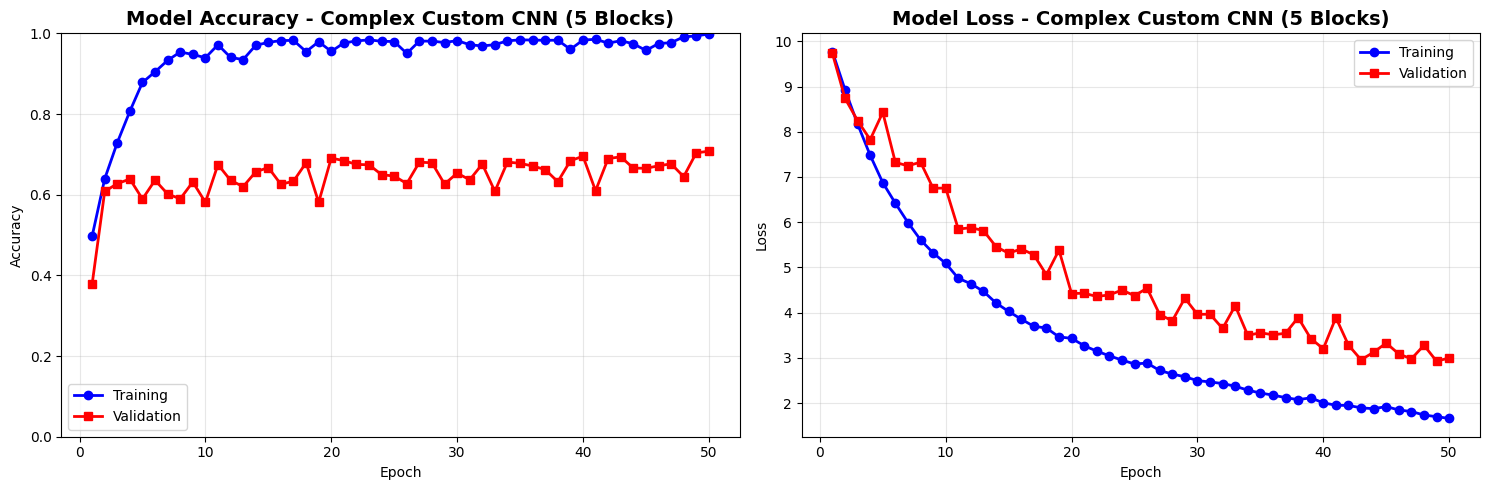

In [ ]:
# =============================================================================
# COMPLEX CUSTOM CNN TRAINING PIPELINE
# =============================================================================

# Training configuration for Complex CNN
COMPLEX_EPOCHS = 50  # More epochs for complex model

# Callbacks for Complex CNN
callbacks_complex = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,  # More patience for complex model
        restore_best_weights=True,
        verbose=1
    ),
    
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    keras.callbacks.ModelCheckpoint(
        filepath=MODELS_DIR / "best_complex_cnn.keras",
        monitor=VAL_METRIC_NAME,
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    keras.callbacks.TensorBoard(
        log_dir=RUNS_DIR / "tensorboard" / "complex_cnn",
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch'
    )
]

print("=" * 70)
print("COMPLEX CUSTOM CNN TRAINING CONFIGURATION")
print("=" * 70)
print(f"Maximum epochs: {COMPLEX_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMG_SIZE}")
print(f"Data augmentation: {AUGMENT}")
print(f"Class weights: Enabled")
print(f"Architecture: 5 blocks × 3 conv layers = 15 conv layers")
print(f"Parameters: {cnn_complex.count_params():,}")
print("=" * 70)

# Create run directory
run_dir_complex = make_run_dir("complex_cnn_5blocks")

# Train Complex CNN model
print("\n" + "=" * 70)
print("PHASE 1: TRAINING COMPLEX CUSTOM CNN")
print("=" * 70)

complex_trained, complex_history, train_time = train_model(
    model=cnn_complex,
    train_dataset=train_gen, 
    val_dataset=val_gen,      
    model_name="complex_cnn",
    run_dir=run_dir_complex,
    class_labels=CLASS_LABELS,
    epochs=COMPLEX_EPOCHS,
    callbacks=callbacks_complex,
    class_weights=CLASS_WEIGHTS
)

# Show training results
print_training_summary(complex_history, "Complex Custom CNN (5 Blocks)")

# Plot training history
plot_training_history(
    complex_history, 
    "Complex Custom CNN (5 Blocks)", 
    save_path=run_dir_complex / "training_history.png"
)

### **Evaluating the Model on Test Set**


PHASE 2: EVALUATION COMPLEX CUSTOM CNN
Starting evaluation for complex_cnn...


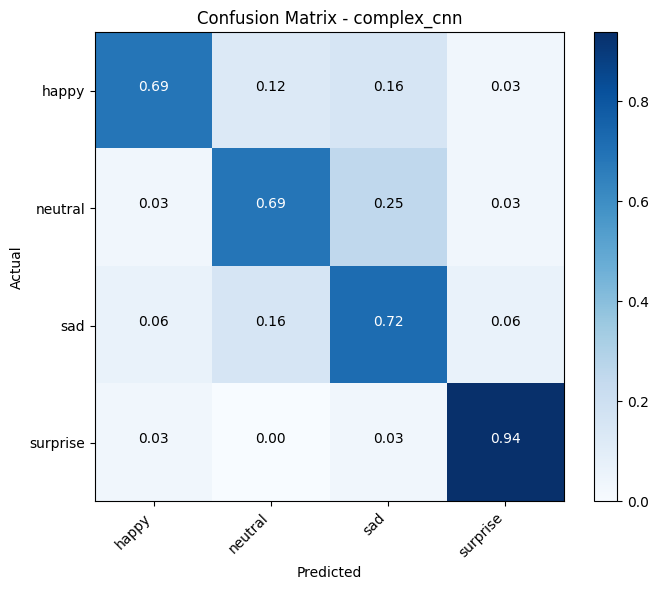


EVALUATION RESULTS - COMPLEX CUSTOM CNN (5 BLOCKS)
Test accuracy: 0.758
Test macro F1: 0.758
Test weighted F1: 0.758

✓ Complex Custom CNN Training and Evaluation Complete!


In [ ]:
# =============================================================================
# COMPLEX CUSTOM CNN EVALUATION PIPELINE
# =============================================================================

print("\n" + "=" * 70)
print("PHASE 2: EVALUATION COMPLEX CUSTOM CNN")
print("=" * 70)

# Evaluate on test set
complex_test_metrics = evaluate_model(
    model=complex_trained,
    test_dataset=test_gen,  # Using grayscale data
    model_name="complex_cnn",
    run_dir=run_dir_complex,
    class_labels=CLASS_LABELS
)

# Show evaluation results
print_evaluation_summary(complex_test_metrics, "Complex Custom CNN (5 Blocks)")

# Create summary row for model comparison
complex_summary = create_model_summary(
    complex_trained, 
    complex_history, 
    complex_test_metrics, 
    "Complex-CNN-5Blocks",
    training_time=train_time
)
append_summary_row(complex_summary)

# Save hyperparameters
save_metrics(
    {
        "name": "Complex Custom CNN (5 Blocks)",
        "architecture": "Custom CNN",
        "channels": [64, 128, 512, 512, 128],
        "convs_per_block": 2,
        "dropout_head": 0.3,
        "activation": "leakyrelu",
        "l2_reg": 0.001,
        "lr": 0.0001,
        "img_size": list(IMAGE_SHAPE),
        "batch_size": BATCH_SIZE,
        "color_mode": COLOR_MODE,
        "augment": AUGMENT,
        "epochs": COMPLEX_EPOCHS,
        "total_layers": "5 blocks × 3 conv = 15 conv layers",
        "data_type": "grayscale"
    },
    run_dir_complex / "hparams.json"
)

print("\n" + "=" * 70)
print("✓ Complex Custom CNN Training and Evaluation Complete!")
print("=" * 70)

**Observations and Insights:__**

In [ ]:
# =============================================================================
# FINAL MODEL COMPARISON
# =============================================================================

print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON - ALL MODELS")
print("=" * 100)

# Load summary CSV
if SUMMARY_CSV.exists():
    df_summary = pd.read_csv(SUMMARY_CSV)
    
    # Sort by Test Accuracy
    df_summary = df_summary.sort_values('Test_Accuracy', ascending=False)
    
    # Display table
    display_df(df_summary, rows=0, show_index=False)
    
    # Visualization comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Test Accuracy comparison
    axes[0, 0].barh(df_summary['Model'], df_summary['Test_Accuracy'])
    axes[0, 0].set_xlabel('Test Accuracy')
    axes[0, 0].set_title('Test Accuracy Comparison')
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # 2. Parameters comparison
    axes[0, 1].barh(df_summary['Model'], df_summary['Parameters'] / 1e6)
    axes[0, 1].set_xlabel('Parameters (Millions)')
    axes[0, 1].set_title('Model Complexity Comparison')
    axes[0, 1].grid(axis='x', alpha=0.3)
    
    # 3. Training Time comparison
    if 'Training_Time_Minutes' in df_summary.columns:
        axes[1, 0].barh(df_summary['Model'], df_summary['Training_Time_Minutes'])
        axes[1, 0].set_xlabel('Training Time (Minutes)')
        axes[1, 0].set_title('Training Time Comparison')
        axes[1, 0].grid(axis='x', alpha=0.3)
    
    # 4. Efficiency (Accuracy per Million Parameters)
    efficiency = df_summary['Test_Accuracy'] / (df_summary['Parameters'] / 1e6)
    axes[1, 1].barh(df_summary['Model'], efficiency)
    axes[1, 1].set_xlabel('Accuracy per Million Parameters')
    axes[1, 1].set_title('Model Efficiency Comparison')
    axes[1, 1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "final_model_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print best model
    best_model = df_summary.iloc[0]
    print("\n" + "=" * 100)
    print("BEST MODEL")
    print("=" * 100)
    print(f"Model: {best_model['Model']}")
    print(f"Test Accuracy: {best_model['Test_Accuracy']:.3f}")
    print(f"Test Macro F1: {best_model['Test_Macro_F1']:.3f}")
    print(f"Parameters: {best_model['Parameters']:,}")
    if 'Training_Time_Minutes' in best_model:
        print(f"Training Time: {best_model['Training_Time_Minutes']:.1f} minutes")
    print("=" * 100)
else:
    print("No summary CSV found!")

In [ ]:
# =============================================================================
# VIEW TRAINING PROGRESS IN TENSORBOARD
# =============================================================================

print("\n" + "=" * 100)
print("📊 TENSORBOARD VISUALIZATION")
print("=" * 100)
print("\nTo view all training runs in TensorBoard:")
print("\n### Option 1: Local")
print("1. Open new terminal")
print("2. Run: tensorboard --logdir=runs/tensorboard")
print("3. Open: http://localhost:6006")
print("\n### Option 2: Docker")
print("docker exec -d facial-emotion-recognition-gpu tensorboard --logdir=/workspace/runs/tensorboard --host=0.0.0.0 --port=6006")
print("Then open: http://localhost:6006")
print("\n### What you can see:")
print("- Training and validation accuracy curves")
print("- Loss curves for all models")
print("- Learning rate changes")
print("- Model graphs")
print("- Histogram of weights and gradients")
print("- Side-by-side comparison of all models")
print("=" * 100)

In [ ]:
# =============================================================================
# FULL TRAINING RUN - COMPLETION
# =============================================================================

FULL_RUN_END_TIME = time.time()
FULL_RUN_END_STR = time.strftime("%Y-%m-%d %H:%M:%S")
FULL_RUN_DURATION = FULL_RUN_END_TIME - FULL_RUN_START_TIME

print("\n" + "=" * 100)
print("FULL TRAINING RUN COMPLETED")
print("=" * 100)
print(f"Started: {FULL_RUN_START_STR}")
print(f"Ended: {FULL_RUN_END_STR}")
print(f"Total Duration: {FULL_RUN_DURATION/3600:.2f} hours ({FULL_RUN_DURATION/60:.1f} minutes)")
print("")
print("All models trained and evaluated successfully!")
print("Check REPORTS_DIR for final comparison and visualizations.")
print("=" * 100)

# Save overall run statistics
save_metrics(
    {
        "full_run_start": FULL_RUN_START_STR,
        "full_run_end": FULL_RUN_END_STR,
        "total_duration_hours": FULL_RUN_DURATION / 3600,
        "total_duration_minutes": FULL_RUN_DURATION / 60,
        "models_trained": 6,
        "random_seed": RANDOM_SEED
    },
    REPORTS_DIR / "full_run_stats.json"
)

### **Plotting the Confusion Matrix for the chosen final model**

**Observations and Insights:__**

## **Conclusion:____________**

### **Insights**

### **Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

### **Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

### **Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?